# Solutions — Lagrangian Trajectory Modelling in the Gulf of Guinea with OpenDrift
### Worked answers to all exercises from `OpenDrift_GulfOfGuinea_SummerSchool_1_.ipynb`
!["lagrangian schematic"](figures/lagrangian_modelling_schematic_GGOSSS2026.png)

**GGOSSS Summer School — Physical Oceanography & Operational Forecasting Track**
**Instructors:** 
- Fernand Assene     — NASMOST, University of Ebolowa, Kribi, Cameroon — fernandassene@hotmail.com
- Ibrahima sidiki BA — LPAOF/ESP, Université Cheikh Anta Diop de Dakar — ibrahimasidiki.ba@ucad.edu.sn
- Hugo Plombat       — University of Michigan                          — plombat@umich.edu 
---

## How to use this notebook

This notebook is **self-contained**: it re-creates the readers from the files in `data/` and re-runs every
simulation it needs (with the same configuration as the teaching notebook, but fewer elements per oil run to
keep it fast). Outputs are written to `outputs/`. It uses the shared helpers of `gog_drift_utils.py`.

Each exercise below repeats the prompt, then gives, question by question:

1. **Worked code** that computes the requested quantity/figure.
2. A **model answer / discussion**. The questions are deliberately ordered *describe first, explain afterwards*:
   the answers follow the same order.

> **Honesty note.** The discussion texts describe what to look for and the physically expected behaviour; they do
> not quote numbers, because *your* numbers depend on the forcing files and dates. Always read the printed
> values first and adapt the discussion to them — a result that departs from the "expected" behaviour is not a
> failure, it is something to explain.

> **Sample data.** The files currently in `data/` are placeholders used to check that the code runs; they do not
> cover the Gulf of Guinea scenario (see the configuration cell of the teaching notebook). Results obtained with
> them are not physically meaningful.

In [1]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean  # registers 'cmo.*' colormaps used below
from pathlib import Path
from datetime import datetime, timedelta
from IPython.display import Markdown, display

from opendrift.readers import reader_netCDF_CF_generic, reader_ROMS_native
from opendrift.models.openoil import OpenOil
from opendrift.models.leeway import Leeway
from opendrift.models.oceandrift import OceanDrift

import gog_drift_utils as gu
PC = ccrs.PlateCarree()

In [9]:
# ============ CONFIGURATION: keep identical to the configuration cell of the teaching notebook ============
DATA_DIR = Path("data")
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
DOWNLOAD_DATA = False

lon_min, lon_max = -12.0, 15.0
lat_min, lat_max = -8.0, 10.0
start = datetime(2026, 3, 1)
end   = datetime(2026, 3, 10)    # minimum 10-day window: enough for a spill/SAR case study

glorys_file = DATA_DIR / "MERCATOR_2026_03_05.nc"   # GLORYS12-type product on a regular lon/lat grid (daily means)
croco_file  = DATA_DIR / "croco_his.nc"              # CROCO history file (native s-coordinates, C-grid)
era5_wind_components = [DATA_DIR / "ARCO_u10_20260201_20260630.nc",   # ERA5 10 m wind: u10 and v10 may be
                        DATA_DIR / "ARCO_v10_20260201_20260630.nc"]   # in one file or in two separate files
wind_file   = DATA_DIR / "era5_wind_gog.nc"          # merged, CF-compliant wind file built in Part 1.4

glorys_fc_file = DATA_DIR / "glorys_forecast_gog.nc"
croco_fc_file  = croco_file
croco_yorig = 1993                     # Yorig of the CROCO run (time origin of its "seconds since initialization")
gfs_file       = DATA_DIR / "gfs_wind_gog_forecast.nc"

release_lon, release_lat = 9.42, 2.78
release_time = start + timedelta(hours=2)
oil_mass_kg  = 300_000
last_known_position = (9.55, 3.05)
incident_time = start + timedelta(hours=6)
river_mouths = {                                 # plastic sources: lon, lat of river mouths
    "Sanaga": (9.63, 3.55),
    "Nyong":  (9.9, 3.25),
}
# ------------------------------------ solutions-specific settings ------------------------------------
N_OIL = 1000                 # elements per oil run (2000 in the teaching notebook): halves the run time
N_PLASTIC = 500              # elements per plastic source
RUN_OPTIONAL = True          # run the optional "going further" question of Exercise 3.2
wouri_mouth = (9.68, 4.05)
person_category = "Person-in-water (PIW), unknown state (mean values)"
vessel_category = "Fishing vessel, general (mean values)"
gfs_cycle = start.replace(hour=0)       # archived GFS cycle for Exercise 7.1 (must lie inside the ERA5 file)
gfs_leads = range(0, 73, 6)             # forecast lead times (h) compared with ERA5
gfs_archive_file = DATA_DIR / f"gfs_{gfs_cycle:%Y%m%d%H}_10m_wind.nc"

# Coastal sectors for Exercise 5.2 / 6.4: boxes (lon_min, lon_max, lat_min, lat_max) around stretches of coast.
# The first box containing a stranded particle wins; stranded particles outside every box -> 'other coast'.
coastal_sectors = {
    "Niger Delta coast (Nigeria)":        (5.0, 8.0, 4.0, 5.0),
    "Rio del Rey / Bakassi":              (8.0, 9.0, 4.2, 5.0),
    "Bioko Island":                       (8.3, 9.0, 3.1, 3.85),
    "Limbe / Mt Cameroon coast":          (8.8, 9.45, 3.85, 4.2),
    "Wouri estuary (Douala)":             (9.45, 10.0, 3.7, 4.3),
    "Sanaga-Nyong coast":                 (9.5, 10.2, 3.15, 3.7),
    "Kribi coast":                        (9.6, 10.2, 2.6, 3.15),
    "Campo / Rio Muni (S of 2.6N)":       (9.0, 10.5, 1.0, 2.6),
}

In [10]:
# ------------------------------------------------ readers ------------------------------------------------
gu.prepare_wind_file(era5_wind_components, wind_file)
reader_glorys = reader_netCDF_CF_generic.Reader(str(glorys_file))

croco_masks = gu.croco_gridfile(croco_file, DATA_DIR / f"{croco_file.stem}_uv_masks.nc")   # u/v masks if missing
ds_c = xr.open_dataset(croco_file, decode_times=False)
time_var = "time"
if time_var in ds_c.variables:
    ds_c[time_var].attrs["units"] = f"seconds since {croco_yorig}-01-01 00:00:00"
reader_croco = reader_ROMS_native.Reader(ds_c, name=croco_file.name, gridfile=croco_masks and str(croco_masks))

reader_wind   = reader_netCDF_CF_generic.Reader(str(wind_file))
gu.check_coverage([reader_glorys, reader_croco, reader_wind],
                  release_lon, release_lat, release_time, release_time + timedelta(hours=72));
for name, (x, y) in {"SAR last known position": last_known_position, **river_mouths, "Wouri": wouri_mouth}.items():
    if gu.is_land(x, y)[0]:
        print(f"note: {name} ({x}, {y}) is on land in GSHHG -> elements are moved to the nearest ocean position")

# ----------------------------- simulation helpers (same settings as the teaching notebook) ---------------
def run_oil(ocean_reader, lon=release_lon, lat=release_lat, time=release_time, oil_type="GENERIC MEDIUM CRUDE",
            three_d=False, vertical_advection=False, duration_h=72, number=N_OIL, wind_reader=None, outfile=None):
    # 2D (Part 2) or 3D (Part 3) OpenOil run of the 300 t release
    o = OpenOil(loglevel=50)
    o.add_reader([ocean_reader, wind_reader or reader_wind])
    o.set_config('seed:oil_type', oil_type)
    o.set_config('processes:evaporation', True)
    o.set_config('processes:emulsification', True)
    o.set_config('processes:dispersion', three_d)
    o.set_config('drift:vertical_mixing', three_d)
    if three_d:
        o.set_config('vertical_mixing:diffusivitymodel', 'windspeed_Large1994')
        o.set_config('vertical_mixing:timestep', 60)
    o.set_config('drift:vertical_advection', vertical_advection)
    o.set_config('drift:current_uncertainty', 0.1)
    o.set_config('drift:wind_uncertainty', 1.0)
    o.set_config('general:coastline_action', 'stranding')
    gu.seed_oil_mass(o, oil_mass_kg, lon=lon, lat=lat, radius=100, number=number, time=time, z=0)
    o.run(duration=timedelta(hours=duration_h), time_step=900, time_step_output=3600,
          outfile=None if outfile is None else str(OUT_DIR / outfile))
    return o


def run_leeway(ocean_reader, category, lon=last_known_position[0], lat=last_known_position[1],
               time=incident_time, duration_h=48, number=1000, outfile=None):
    s = Leeway(loglevel=50)
    s.add_reader([ocean_reader, reader_wind])
    s.set_config('seed:object_type', category)
    s.seed_elements(lon=lon, lat=lat, time=time, number=number, radius=500)
    s.run(duration=timedelta(hours=duration_h), time_step=600, time_step_output=1800,
          outfile=None if outfile is None else str(OUT_DIR / outfile))
    return s


def run_plastic(ocean_reader, sources, coastline_action="stranding", number=N_PLASTIC, outfile=None):
    p = OceanDrift(loglevel=50)
    p.add_reader([ocean_reader, reader_wind])
    p.set_config('drift:advection_scheme', 'runge-kutta4')
    p.set_config('drift:vertical_mixing', False)
    p.set_config('drift:current_uncertainty', 0.05)
    p.set_config('drift:wind_uncertainty', 0.5)
    p.set_config('general:coastline_action', coastline_action)
    for i, (name, (slon, slat)) in enumerate(sources.items()):
        p.seed_elements(lon=slon, lat=slat, radius=1000, number=number,
                        time=[start, start + timedelta(days=9)], wind_drift_factor=0.02, origin_marker=i)
    p.run(duration=timedelta(days=20), time_step=1800, time_step_output=3600 * 6,
          outfile=None if outfile is None else str(OUT_DIR / outfile))
    return p


def budget_percent(o):
    # Oil budget (% of released mass) as a DataFrame indexed by hours since release
    b = o.get_oil_budget()
    total = float(b['mass_total'][0])
    hours = (o.result.time.values - o.result.time.values[0]) / np.timedelta64(1, 'h')
    df = pd.DataFrame({k.replace('mass_', ''): 100 * np.asarray(b[k]) / total
                       for k in ['mass_surface', 'mass_submerged', 'mass_stranded', 'mass_evaporated',
                                 'mass_dispersed', 'mass_biodegraded']}, index=hours)
    df['remaining (surface+submerged+stranded)'] = df.surface + df.submerged + df.stranded
    df.index.name = 'hours'
    return df


def summarize(sim, hours=72):
    # Exercise 6.1 / 7.2 metrics for one run
    ds = gu.as_dataset(sim)
    fi = gu.first_impact(ds)
    fin = gu.state_at(ds, hours)
    frac = 100 * gu.stranded_mask(ds, hours).sum() / max(gu.seeded_mask(ds, hours).sum(), 1)
    return {"time to first coastal impact [h]": fi["time_to_first_impact_h"],
            f"fraction reaching the coast at {hours} h [%]": frac,
            f"convex-hull area at {hours} h [km2]": gu.hull_area_km2(fin.lon, fin.lat),
            "first impact lon [deg E]": fi["first_impact_lon"],
            "first impact lat [deg N]": fi["first_impact_lat"]}


def subset_origin(ds, k):
    # Trajectories of one source (origin_marker == k) of a multi-source run
    orig = gu.filled(ds, "origin_marker").isel(time=-1).values
    return ds.isel(trajectory=np.where(orig == k)[0])

                        point_covered  period_covered      start                 end
reader                                                                              
MERCATOR_2026_03_05.nc           True            True 2026-03-01 2026-05-31 00:00:00
croco_his.nc                     True            True 2026-03-01 2026-05-29 00:00:00
era5_wind_gog.nc                 True            True 2026-02-01 2026-06-30 23:00:00


## Exercise 2.1 — Oil-type sensitivity

*Re-run the same oil-spill scenario using `GENERIC LIGHT CRUDE` and `GENERIC HEAVY CRUDE`. Compare the three
simulations over the first 72 hours.*

In [11]:
oil_types = ["GENERIC LIGHT CRUDE", "GENERIC MEDIUM CRUDE", "GENERIC HEAVY CRUDE"]
oil_runs = {ot: run_oil(reader_glorys, oil_type=ot, outfile=f"sol_2_1_{ot.split()[1].lower()}.nc") for ot in oil_types}
budgets = {ot: budget_percent(o) for ot, o in oil_runs.items()}

**Q1 — Evaporation curves.**

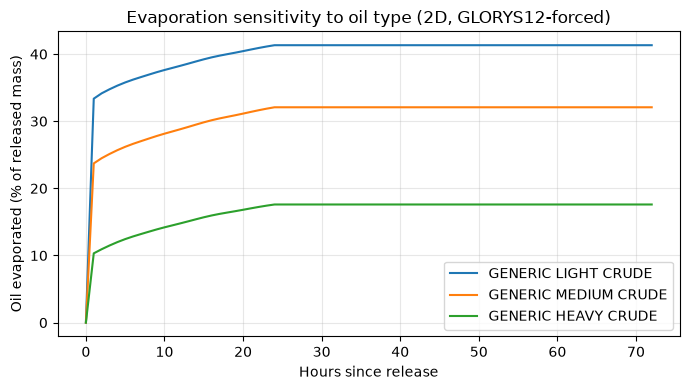

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for ot, b in budgets.items():
    ax.plot(b.index, b.evaporated, label=ot)
ax.set_xlabel("Hours since release"); ax.set_ylabel("Oil evaporated (% of released mass)")
ax.set_title("Evaporation sensitivity to oil type (2D, GLORYS12-forced)"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_2_1_evaporation.png", dpi=150); plt.show()

**Q2 — Oil remaining after 72 h** (remaining = liquid oil still in the system: at the surface, submerged or stranded).

In [13]:
rows = {}
for ot, b in budgets.items():
    last = b.iloc[-1]
    rows[ot] = {"remaining [%]": last['remaining (surface+submerged+stranded)'],
                "remaining [t]": last['remaining (surface+submerged+stranded)'] / 100 * oil_mass_kg / 1000,
                "  of which afloat [%]": last.surface, "  of which stranded [%]": last.stranded,
                "evaporated [%]": last.evaporated, "dispersed [%]": last.dispersed,
                "hours simulated": b.index[-1]}
table_2_1 = pd.DataFrame(rows).T
table_2_1.round(1)

,remaining [%],remaining [t],of which afloat [%],of which stranded [%],evaporated [%],dispersed [%],hours simulated
GENERIC LIGHT CRUDE,58.7,176.0,53.6,5.0,41.3,0.0,72.0
GENERIC MEDIUM CRUDE,67.9,203.8,62.1,5.8,32.1,0.0,72.0
GENERIC HEAVY CRUDE,82.4,247.2,75.3,7.1,17.6,0.0,72.0


**Q3 — What differs (description only).** Read the table and the curves and describe, without explaining:
the ranking of the three oils in evaporated fraction at 72 h; *when* most of the evaporation happens (the
curves are steep during the first hours and then flatten); the ranking in remaining mass; and whether the
stranded fraction differs between oils (with the same currents and wind it usually differs much less than the
evaporated fraction, because all three oils are advected the same way in this 2D configuration).

**Q4 — API gravity of the three oil records.** Bonny Light is typically 35–37° API.

In [14]:
props = pd.DataFrame({ot: gu.oil_properties(o) for ot, o in oil_runs.items()}).T
bonny_api = 36.0
props["|API - 36|"] = (props["API gravity [deg]"] - bonny_api).abs()
display(props.round(2))
print(f"Closest analogue to Bonny Light (~{bonny_api:.0f} deg API): {props['|API - 36|'].idxmin()}")

,API gravity [deg],density @ 15 C [kg/m3],kinematic viscosity @ 15 C [cSt],pour point [C],mass fraction boiling < 200 C [%],max water content of emulsion [%],|API - 36|
GENERIC LIGHT CRUDE,39.11,828.62,7.69,-10.86,32.93,90.00,3.11
GENERIC MEDIUM CRUDE,29.68,877.10,36.82,-15.90,23.20,90.00,6.32
GENERIC HEAVY CRUDE,15.37,962.63,5854.41,-7.51,9.79,45.02,20.63


Closest analogue to Bonny Light (~36 deg API): GENERIC LIGHT CRUDE


**Q5 — Physical explanation, and why API gravity is not enough.**

*Explanation.* Evaporation in OpenOil is computed component by component from the oil's distillation curve
(pseudo-components with their own boiling points and mass fractions, `boiling_point`/`mass_fraction` in the
record). A light crude contains a large fraction of components boiling below ~200 °C, which evaporate within hours
at tropical sea-surface temperatures; a heavy crude contains few of them. The light oil therefore loses more mass
quickly, and less of it remains after 72 h. Emulsification (water uptake) also depends on the oil: heavier, more
viscous oils emulsify earlier and more strongly, which further slows evaporation (the evaporating surface is
reduced) and increases the volume and viscosity of what remains.

*Why API gravity is not sufficient.* API gravity is a single number describing the **bulk density**. Two oils with the
same API can have very different:
- **distillation curves** (the table's "mass fraction boiling < 200 °C"): this, not density, controls evaporation;
- **viscosity** and **pour point**: they control spreading, natural dispersion (droplet sizes), and whether the oil
  solidifies at sea-surface temperature (a high pour point / waxy crude behaves very differently);
- **asphaltene/resin content**, reflected in the maximum water content of the emulsion: controls emulsification.

In the table, compare the viscosity, pour point and light fraction of the three records, not only their API.
Operationally one would select a *named* record from the ADIOS database (e.g. search for "BONNY LIGHT" in
`OpenOil(...).oiltypes`), which carries a measured distillation curve, instead of a generic analogue.

## Exercise 2.2 — Effect of the release position

*Move the release location approximately 15 km offshore while keeping the other settings unchanged.*

**Q1 — Original and modified release locations.** The offshore direction is chosen automatically (land-free path, end point as far as possible from land).

original release : (9.420, 2.780)  ~50.0 km from the nearest coast
offshore release : (9.290, 2.815)  bearing 285 deg, ~64.5 km from the nearest coast


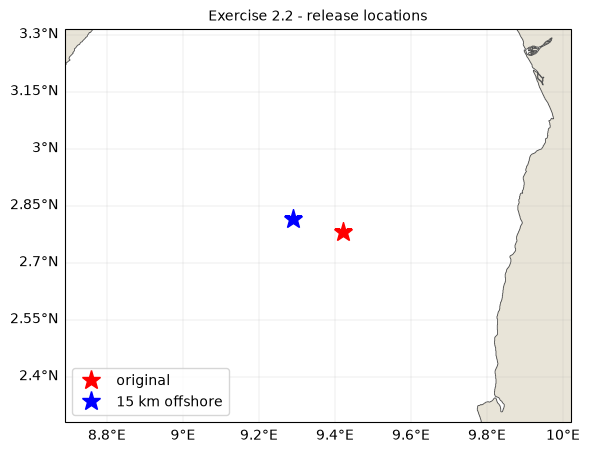

In [15]:
off_lon, off_lat, off_bearing = gu.offshore_point(release_lon, release_lat, 15.0)
d0 = gu.distance_to_coast_km(release_lon, release_lat)
d1 = gu.distance_to_coast_km(off_lon, off_lat)
print(f"original release : ({release_lon:.3f}, {release_lat:.3f})  ~{d0:.1f} km from the nearest coast")
print(f"offshore release : ({off_lon:.3f}, {off_lat:.3f})  bearing {off_bearing:.0f} deg, ~{d1:.1f} km from the nearest coast")

pts = [(release_lon, release_lat), (off_lon, off_lat)]
ext = gu.extent_of(points=pts, pad=0) ; ext = [ext[0] - 0.6, ext[1] + 0.6, ext[2] - 0.5, ext[3] + 0.5]
fig = plt.figure(figsize=(6, 6))
ax = gu.map_axes(fig, extent=ext, title="Exercise 2.2 - release locations")
ax.plot(release_lon, release_lat, 'r*', ms=14, transform=PC, zorder=6, label="original")
ax.plot(off_lon, off_lat, 'b*', ms=14, transform=PC, zorder=6, label="15 km offshore")
ax.legend(loc="lower left"); plt.savefig(OUT_DIR / "solution_2_2_release_points.png", dpi=150); plt.show()

**Q2 — 72 h runs for both locations** (the original run is the medium-crude run of Exercise 2.1: same settings).

In [16]:
o_near = oil_runs["GENERIC MEDIUM CRUDE"]
o_off = run_oil(reader_glorys, lon=off_lon, lat=off_lat, outfile="sol_2_2_offshore.nc")

**Q3 — Fraction of particles reaching the coastline, and particle distributions.**

,original,15 km offshore
time to first coastal impact [h],65.00,NaN
fraction reaching the coast at 72 h [%],8.60,0.00
convex-hull area at 72 h [km2],62.42,60.20
first impact lon [deg E],9.91,NaN
first impact lat [deg N],3.23,NaN
centroid_lon,9.87,9.78
centroid_lat,3.29,3.35
std_major_km,2.77,2.18
std_minor_km,0.96,0.90


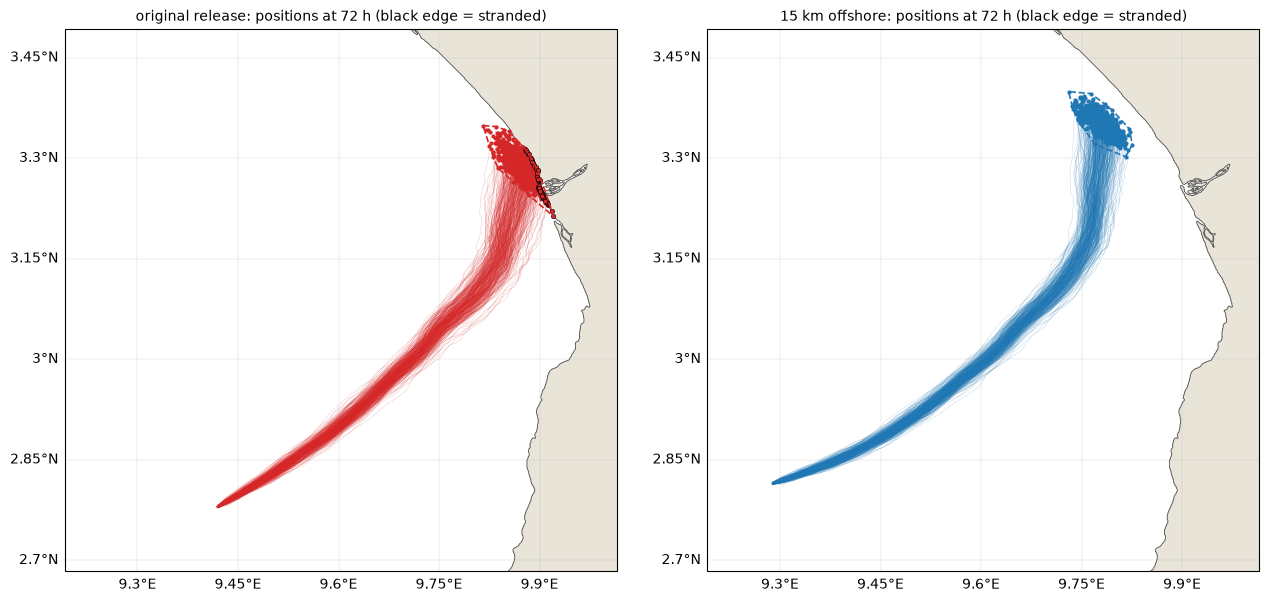

In [17]:
res = {}
for label, o in [("original", o_near), ("15 km offshore", o_off)]:
    s = summarize(o, 72)
    s.update({k: v for k, v in gu.ensemble_shape(*gu.state_at(o.result, 72)[["lon", "lat"]].values.T).items()
              if k in ("centroid_lon", "centroid_lat", "std_major_km", "std_minor_km")})
    res[label] = s
display(pd.DataFrame(res).round(2))

ext = gu.extent_of(o_near.result, o_off.result)
fig = plt.figure(figsize=(13, 6))
for k, (o, title, col) in enumerate([(o_near, "original release", "C3"), (o_off, "15 km offshore", "C0")]):
    ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, k + 1), title=f"{title}: positions at 72 h (black edge = stranded)")
    gu.plot_ensemble(ax, o.result, color=col, hull=True)
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_2_2_distributions.png", dpi=150); plt.show()

**Q4 — Discussion.**

*Distance.* The initial distance to the coast sets a minimum transit time: with a typical net drift of
0.2–0.5 m/s (current + ~3 % of the wind for surface oil), 15 km more takes ~8–20 h more, i.e. a delayed first
impact and, for a fixed 72 h window, fewer elements reaching the coast. The ensemble also has more time to spread
before landfall, so the impacted stretch of coast tends to be longer but less concentrated.

*Other factors* that can explain part of the difference (check them against your maps):
- **the local current field is different at the two points**: 15 km offshore the release may sit in a different
  part of the shelf circulation (e.g. further from a coastal jet, or on the other side of a front/eddy) and be
  advected *along* rather than *towards* the coast; the offshore release may even never reach the coast;
- **the wind direction relative to the coastline** during the specific 72 h (onshore vs alongshore wind);
- **the coastline geometry** downstream (headlands, estuaries) and the spatial resolution of the forcing near the
  coast (a coarse model has few wet points in the first 10 km);
- **weathering during the longer transit**: oil that travels longer before reaching the coast has evaporated and
  emulsified more, so the *mass* stranded differs even more than the *number* of elements stranded.

## Exercise 3.1 — Effect of wind conditions on oil dispersion

*Select one relatively low-wind and one relatively high-wind period from the available atmospheric forcing and
run the same (3D) oil-spill scenario for both periods.*

Periods are selected objectively: among all 48 h windows starting at 00 or 12 UTC that are covered by *both*
the ocean and the wind forcing, we take the windows with the lowest and highest mean wind speed in a
1°×1° box around the release point.

In [18]:
with xr.open_dataset(wind_file) as w:
    w = w.sel(longitude=slice(release_lon - 0.5, release_lon + 0.5), latitude=slice(release_lat - 0.5, release_lat + 0.5))
    spd = np.hypot(w.x_wind, w.y_wind).mean(["latitude", "longitude"]).to_series()

t_first = max(pd.Timestamp(reader_glorys.start_time), spd.index[0])
t_last  = min(pd.Timestamp(reader_glorys.end_time), spd.index[-1]) - pd.Timedelta(hours=48)
if t_last <= t_first:
    warnings.warn("Ocean and wind forcing do not overlap by 48 h: selecting periods from the wind record only.")
    t_first, t_last = spd.index[0], spd.index[-1] - pd.Timedelta(hours=48)
candidates = pd.date_range(t_first.ceil("12h"), t_last, freq="12h")
mean48 = pd.Series({t: spd[t:t + pd.Timedelta(hours=48)].mean() for t in candidates})
periods = {"low wind": mean48.idxmin().to_pydatetime(), "high wind": mean48.idxmax().to_pydatetime()}
print({k: f"{v:%Y-%m-%d %H UTC}" for k, v in periods.items()})

wind_runs = {k: run_oil(reader_glorys, time=t, three_d=True, duration_h=48, outfile=f"sol_3_1_{k.replace(' ', '_')}.nc")
             for k, t in periods.items()}

{'low wind': '2026-03-30 12 UTC', 'high wind': '2026-05-13 12 UTC'}


**Q1 — Wind conditions during the two simulations** (box around the release point, from the forcing file; and as experienced by the oil elements).

In [19]:
rows = {}
for k, t in periods.items():
    s = gu.wind_speed_stats(wind_file, release_lon, release_lat, t, t + timedelta(hours=48))
    r = wind_runs[k].result
    if "x_wind" in r:
        el = np.hypot(r.x_wind, r.y_wind)
        s["mean wind at elements [m/s]"] = float(el.mean())
        s["max wind at elements [m/s]"] = float(el.max())
    rows[k] = s
wind_table = pd.DataFrame(rows).T.rename(columns={"mean_wind_ms": "mean wind [m/s]", "max_wind_ms": "max wind [m/s]",
                                                  "mean_wind_cubed_m3s3": "mean U^3 [m3/s3]"})
wind_table.round(2)

,mean wind [m/s],max wind [m/s],mean U^3 [m3/s3],n_times,mean wind at elements [m/s],max wind at elements [m/s]
low wind,2.00,4.35,12.14,49.0,2.34,6.53
high wind,4.75,7.25,130.30,49.0,4.67,10.55


**Q2 — Oil dispersed into the water column after 48 h.**

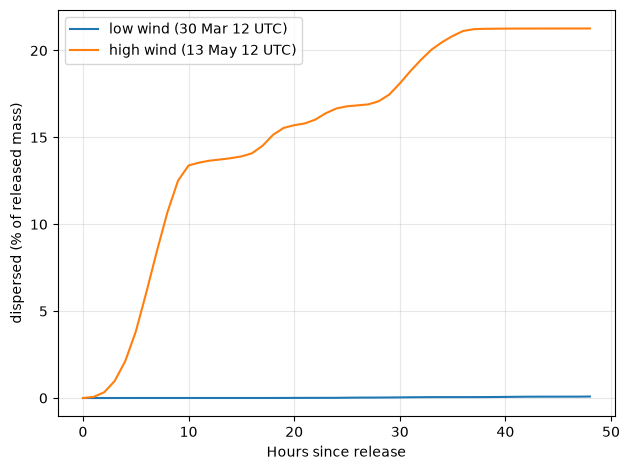

,dispersed at 48 h [%],submerged at 48 h [%],evaporated at 48 h [%],surface at 48 h [%]
low wind,0.09,0.00,29.540001,70.379997
high wind,21.27,2.83,31.629999,44.270000


In [20]:
disp = {}
for k, o in wind_runs.items():
    b = budget_percent(o)
    disp[k] = {"dispersed at 48 h [%]": b.dispersed.iloc[-1], "submerged at 48 h [%]": b.submerged.iloc[-1],
               "evaporated at 48 h [%]": b.evaporated.iloc[-1], "surface at 48 h [%]": b.surface.iloc[-1]}
    plt.plot(b.index, b.dispersed, label=f"{k} ({periods[k]:%d %b %H UTC})")
plt.xlabel("Hours since release"); plt.ylabel("dispersed (% of released mass)"); plt.grid(alpha=0.3); plt.legend()
plt.savefig(OUT_DIR / "solution_3_1_dispersion.png", dpi=150); plt.show()
disp_table = pd.DataFrame(disp).T
disp_table.round(2)

**Q3 — Is the response proportional to the change in wind speed?** Compare the ratio (high/low) of the dispersed fraction with the ratios of U, U² and U³.

In [21]:
U = wind_table["mean wind [m/s]"]
D = disp_table["dispersed at 48 h [%]"] + disp_table["submerged at 48 h [%]"]   # all oil below the surface
ratios = pd.Series({
    "U_high / U_low": U["high wind"] / U["low wind"],
    "(U_high / U_low)^2": (U["high wind"] / U["low wind"]) ** 2,
    "(U_high / U_low)^3": (U["high wind"] / U["low wind"]) ** 3,
    "<U^3>_high / <U^3>_low": wind_table.loc["high wind", "mean U^3 [m3/s3]"] / wind_table.loc["low wind", "mean U^3 [m3/s3]"],
    "dispersed+submerged: high / low": D["high wind"] / D["low wind"] if D["low wind"] > 0 else np.inf,
})
display(ratios.round(2).to_frame("ratio"))
r_u, r_d = ratios["U_high / U_low"], ratios["dispersed+submerged: high / low"]
print(f"Wind speed ratio {r_u:.2f} vs dispersed-mass ratio {r_d:.2f} -> "
      + ("roughly proportional" if abs(r_d / r_u - 1) < 0.2 else "NOT proportional to the wind speed"))

,ratio
U_high / U_low,2.38
(U_high / U_low)^2,5.66
(U_high / U_low)^3,13.45
<U^3>_high / <U^3>_low,10.73
dispersed+submerged: high / low,280.42


Wind speed ratio 2.38 vs dispersed-mass ratio 280.42 -> NOT proportional to the wind speed


**Q4 — Why the response is generally not proportional.** Natural dispersion is a threshold-like, strongly
non-linear function of the wind:

- **Wave breaking** is the entrainment mechanism. The dispersion rate in OpenOil scales with the energy
  dissipated by breaking waves, which grows roughly like U³ or faster, and whitecapping is close to zero below
  ~4–5 m/s: a doubling of a light wind can multiply dispersion by far more than two, while the same increase
  in strong winds changes it less once most oil is already entrained.
- **Droplet size and resurfacing**: stronger mixing produces smaller droplets (higher energy) that rise more
  slowly, so they stay submerged longer and a larger fraction is counted as dispersed/submerged at 48 h.
- **Vertical mixing depth** (`windspeed_Large1994`): the diffusivity and mixed-layer depth also increase with the
  wind, pushing droplets deeper.
- **Weathering feedbacks**: evaporation and emulsification raise viscosity with time, which reduces dispersion
  (viscous emulsions are hardly dispersible). A run with stronger early winds disperses the oil *before* it
  becomes viscous; the timing of the wind within the 48 h matters, not only its mean — compare mean and max
  winds in Q1.
- **Wave field not in equilibrium with the wind**: without a wave reader, OpenDrift estimates wave height and
  period from the local wind (fully-developed sea); real waves depend on fetch, duration and swell (important
  in the Gulf of Guinea), which can decouple dispersion from the local wind.

## Exercise 3.2 — Two-dimensional versus three-dimensional transport

*Compare the 72-hour simulations performed with the 2D and the 3D configurations.*

In [22]:
o2 = oil_runs["GENERIC MEDIUM CRUDE"]                                     # 2D run (Exercise 2.1)
o3 = run_oil(reader_glorys, three_d=True, outfile="sol_3_2_3d.nc")        # 3D run, same seed
fin2, fin3 = gu.state_at(o2.result, 72), gu.state_at(o3.result, 72)
surf3 = fin3.z.values > -0.01          # elements at the surface in the 3D run (incl. stranded ones)

**Q1 — Surface distributions and surface footprints.**

,n elements,hull area [km2],centroid lon,centroid lat,std major axis [km],std minor axis [km],major axis bearing [deg]
2D (all elements),1000.0,62.42,9.87,3.29,2.77,0.96,142.43
3D surface elements,990.0,294.41,9.87,3.29,3.05,1.31,147.94
3D all elements,1000.0,828.60,9.87,3.28,4.09,2.50,8.06


Centroid separation 2D vs 3D-surface: 0.3 km


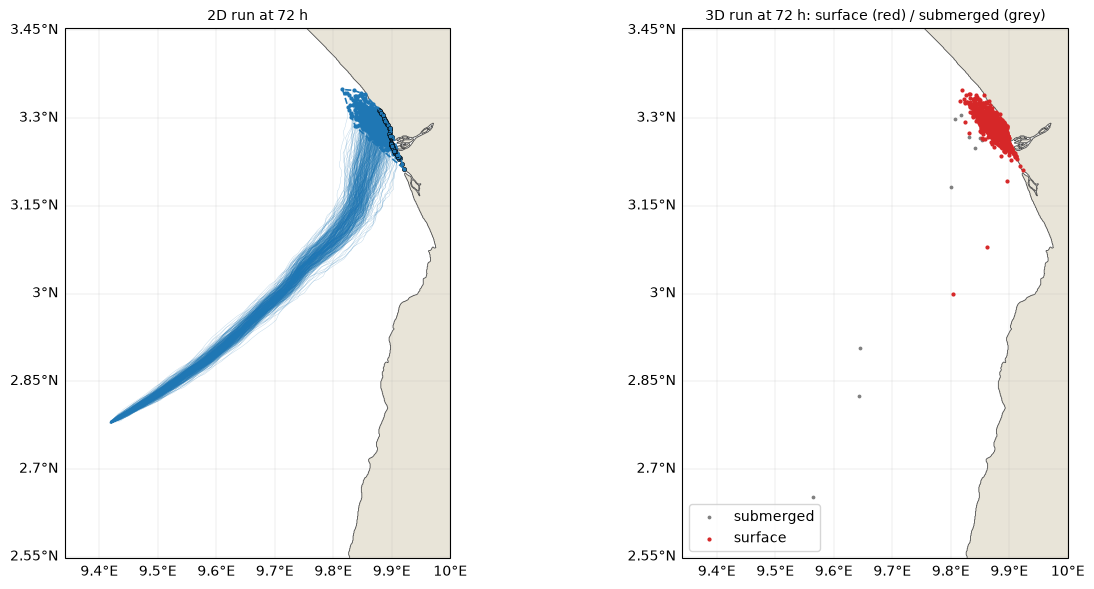

In [23]:
rows = {}
for label, lon, lat in [("2D (all elements)", fin2.lon, fin2.lat),
                        ("3D surface elements", fin3.lon[surf3], fin3.lat[surf3]),
                        ("3D all elements", fin3.lon, fin3.lat)]:
    shp = gu.ensemble_shape(lon, lat)
    rows[label] = {"n elements": shp["n"], "hull area [km2]": gu.hull_area_km2(lon, lat),
                   "centroid lon": shp["centroid_lon"], "centroid lat": shp["centroid_lat"],
                   "std major axis [km]": shp["std_major_km"], "std minor axis [km]": shp["std_minor_km"],
                   "major axis bearing [deg]": shp["major_axis_bearing_deg"]}
display(pd.DataFrame(rows).T.round(2))
print(f"Centroid separation 2D vs 3D-surface: "
      f"{gu.haversine_km(rows['2D (all elements)']['centroid lon'], rows['2D (all elements)']['centroid lat'], rows['3D surface elements']['centroid lon'], rows['3D surface elements']['centroid lat']):.1f} km")

ext = gu.extent_of(o2.result, o3.result)
fig = plt.figure(figsize=(13, 6))
ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, 1), title="2D run at 72 h")
gu.plot_ensemble(ax, o2.result, color="C0", hull=True)
ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, 2), title="3D run at 72 h: surface (red) / submerged (grey)")
ax.scatter(fin3.lon[~surf3], fin3.lat[~surf3], s=3, color="0.5", transform=PC, zorder=4, label="submerged")
ax.scatter(fin3.lon[surf3], fin3.lat[surf3], s=4, color="C3", transform=PC, zorder=5, label="surface")
ax.legend(loc="lower left")
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_3_2_footprint_2d_vs_3d.png", dpi=150); plt.show()

**Q2 — Vertical distribution in the 3D run.**

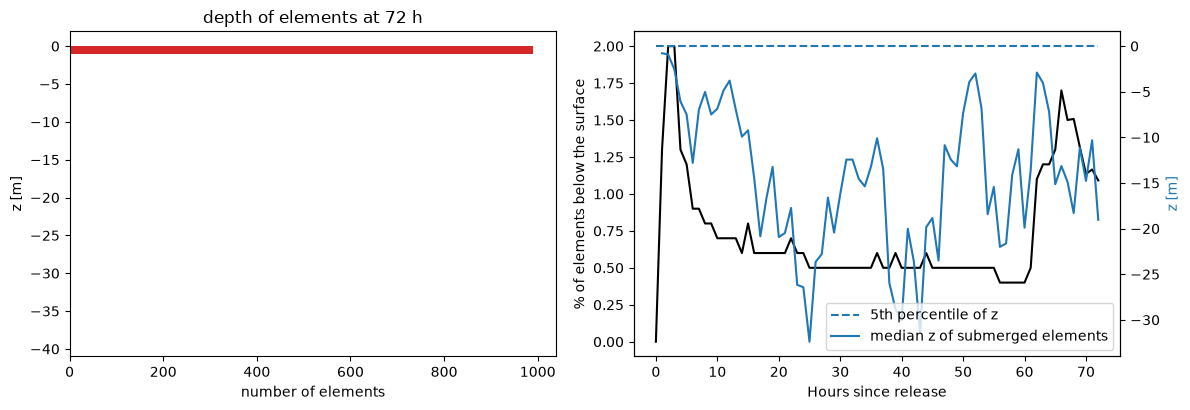

At 72 h: 1 % of elements submerged; deepest -39.0 m; median depth of submerged elements -19.04 m


In [24]:
z = o3.result.z
hours = (o3.result.time - o3.result.time[0]) / np.timedelta64(1, 'h')
frac_sub = 100 * (z < -0.01).sum("trajectory") / z.notnull().sum("trajectory")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(fin3.z.dropna(), bins=40, orientation="horizontal", color="C3")
axes[0].set_xlabel("number of elements"); axes[0].set_ylabel("z [m]"); axes[0].set_title("depth of elements at 72 h")
axes[1].plot(hours, frac_sub, "k")
axes[1].set_xlabel("Hours since release"); axes[1].set_ylabel("% of elements below the surface")
ax2 = axes[1].twinx()
ax2.plot(hours, z.quantile(0.05, "trajectory"), "C0--", label="5th percentile of z")
ax2.plot(hours, z.where(z < -0.01).median("trajectory"), "C0", label="median z of submerged elements")
ax2.set_ylabel("z [m]", color="C0"); ax2.legend(loc="lower right")
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_3_2_vertical.png", dpi=150); plt.show()
print(f"At 72 h: {100*(~surf3).mean():.0f} % of elements submerged; deepest {fin3.z.min():.1f} m; "
      f"median depth of submerged elements {fin3.z[~surf3].median() if (~surf3).any() else 0:.2f} m")

**Q3 — Description (no explanation yet).** From the table and figures, state: how many elements remain at the
surface in 3D vs 2D; whether the surface footprint of the 3D run is larger, smaller or just differently
shaped/oriented (hull area, principal axes, bearing); how far apart the two centroids are; what fraction of the
3D elements is submerged and at which depths (usually most submerged elements stay in the upper few metres,
with a tail extending to the mixed-layer depth); and whether this fraction is steady or fluctuates with time
(it typically follows the wind: entrainment during windy periods, resurfacing during calm periods).

**Q4 — Discussion.** In 3D, part of the oil is entrained as droplets by breaking waves and mixed downwards; while
submerged it is **not** subject to the direct wind drag/Stokes drift that dominate the surface drift, and it is
advected by the current *at its depth*. Because currents change with depth (Ekman veering, a sheared coastal jet,
a shallow stratified layer over a counter-current), a submerged element follows a different path, then
resurfaces elsewhere. The resulting surface ensemble is a mixture of elements with different time-at-depth
histories: more spread in the direction of shear, usually less elongated in the downwind direction, and
generally lagging the pure-surface drift. A surface-only (2D) run implicitly assumes every element feels the
wind all the time, so it tends to predict faster downwind transport and a more compact, more wind-aligned slick.
The 3D surface footprint can look smaller because some oil is temporarily "invisible" below the surface; the
water volume exposed to oil is larger.

**Q5 — (Optional) Resolved vertical advection.** GLORYS12 does not provide `w`; the CROCO reader does
(`upward_sea_water_velocity`). We compare two 3D CROCO runs: turbulent mixing only vs. mixing + vertical advection.

In [25]:
if RUN_OPTIONAL:
    o3_mix = run_oil(reader_croco, three_d=True, vertical_advection=False, outfile="sol_3_2_croco_mix.nc")
    o3_w   = run_oil(reader_croco, three_d=True, vertical_advection=True,  outfile="sol_3_2_croco_mix_w.nc")
    rows = {}
    for label, o in [("3D mixing only", o3_mix), ("3D mixing + vertical advection", o3_w)]:
        f = gu.state_at(o.result, 72)
        shp = gu.ensemble_shape(f.lon, f.lat)
        rows[label] = {"% submerged": 100 * (f.z < -0.01).mean(), "median z [m]": f.z.median(), "min z [m]": f.z.min(),
                       "hull area [km2]": gu.hull_area_km2(f.lon, f.lat), "centroid lon": shp["centroid_lon"],
                       "centroid lat": shp["centroid_lat"]}
    t = pd.DataFrame(rows).T
    display(t.round(2))
    print("centroid shift due to w: %.2f km" % gu.haversine_km(*t.iloc[0][["centroid lon", "centroid lat"]],
                                                              *t.iloc[1][["centroid lon", "centroid lat"]]))

,% submerged,median z [m],min z [m],hull area [km2],centroid lon,centroid lat
3D mixing only,0.9,0.0,-45.72,920.16,9.83,3.37
3D mixing + vertical advection,1.0,0.0,-20.29,816.82,9.83,3.37


centroid shift due to w: 0.12 km


Resolved `w` is usually small (10⁻⁵–10⁻⁴ m/s, i.e. ~1–10 m/day) compared with droplet rise velocities
(10⁻³–10⁻² m/s for typical droplets) and with the turbulent velocities in the mixed layer, so it generally
changes the depth distribution — and hence the conclusion of Q4 — only marginally for surface-released oil.
It matters more for very small droplets, near fronts and in strong coastal upwelling/downwelling cells, and over
longer time scales. If your table shows only a small centroid shift and similar depth statistics, that is the
expected result: the conclusion of Q4 (shear + mixing drive the 2D/3D difference) holds.

## Exercise 4.1 — Person-in-water versus drifting vessel

*Compare the simulated trajectories of a person-in-water and a drifting vessel under the same forcing.*

In [26]:
sar_person = run_leeway(reader_croco, person_category, outfile="sol_4_1_person_croco.nc")
sar_vessel = run_leeway(reader_croco, vessel_category, outfile="sol_4_1_vessel_croco.nc")

**Q1 — Trajectories and ensembles** (tracks over 24 h, positions at 24 h).

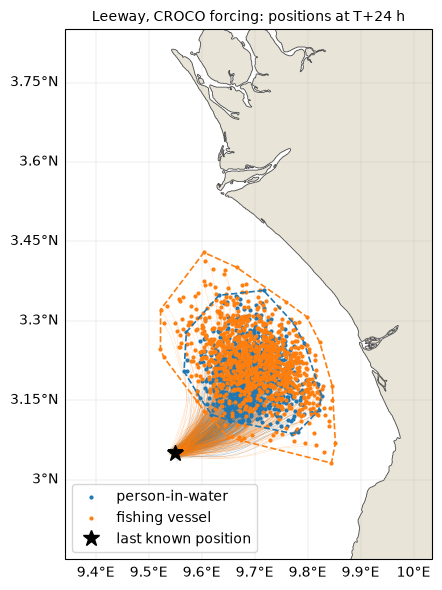

In [27]:
ext = gu.extent_of(sar_person.result, sar_vessel.result, points=[last_known_position])
fig = plt.figure(figsize=(7, 6))
ax = gu.map_axes(fig, extent=ext, title="Leeway, CROCO forcing: positions at T+24 h")
gu.plot_ensemble(ax, sar_person.result, 24, color="C0", label="person-in-water", hull=True)
gu.plot_ensemble(ax, sar_vessel.result, 24, color="C1", label="fishing vessel", hull=True)
ax.plot(*last_known_position, "k*", ms=12, transform=PC, zorder=6, label="last known position")
ax.legend(loc="lower left"); plt.savefig(OUT_DIR / "solution_4_1_person_vs_vessel.png", dpi=150); plt.show()

**Q2 — Positions after 24 h and separation of the centroids.**

In [28]:
rows = {}
for label, s in [("person-in-water", sar_person), ("fishing vessel", sar_vessel)]:
    f = gu.state_at(s.result, 24)
    shp = gu.ensemble_shape(f.lon, f.lat)
    dist = gu.haversine_km(last_known_position[0], last_known_position[1], shp["centroid_lon"], shp["centroid_lat"])
    rows[label] = {"centroid lon": shp["centroid_lon"], "centroid lat": shp["centroid_lat"],
                   "centroid distance from LKP [km]": dist, "mean drift speed [m/s]": dist * 1000 / (24 * 3600),
                   "hull area [km2]": gu.hull_area_km2(f.lon, f.lat), "std major axis [km]": shp["std_major_km"],
                   "stranded [%]": 100 * gu.stranded_mask(s.result, 24).mean()}
t41 = pd.DataFrame(rows).T
display(t41.round(3))
sep_km = gu.haversine_km(*t41.loc["person-in-water", ["centroid lon", "centroid lat"]],
                         *t41.loc["fishing vessel", ["centroid lon", "centroid lat"]])
print(f"Separation between the two ensemble centroids at T+24 h: {sep_km:.1f} km")

,centroid lon,centroid lat,centroid distance from LKP [km],mean drift speed [m/s],hull area [km2],std major axis [km],stranded [%]
person-in-water,9.692,3.198,22.792,0.264,622.545,5.316,0.0
fishing vessel,9.699,3.222,25.322,0.293,1043.481,7.918,0.0


Separation between the two ensemble centroids at T+24 h: 2.8 km


**Q3 — Leeway parameters of the two categories.** Downwind leeway = (DWSLOPE·U₁₀ + DWOFFSET)/100 m/s; crosswind likewise with CWRSLOPE/CWLSLOPE (right/left of downwind). Slopes are in % of the 10 m wind, offsets in cm/s.

In [29]:
table = pd.DataFrame(sar_person.leewayprop).T.set_index("Description")
cols = ["OBJKEY", "DWSLOPE", "DWOFFSET", "DWSTD", "CWRSLOPE", "CWROFFSET", "CWLSLOPE", "CWLOFFSET", "CWRSTD"]
lw = table.loc[[person_category, vessel_category], cols]
display(lw)
U = float(np.hypot(sar_person.result.x_wind, sar_person.result.y_wind).mean()) if "x_wind" in sar_person.result else 6.0
for cat in lw.index:
    dw = (lw.loc[cat, "DWSLOPE"] * U + lw.loc[cat, "DWOFFSET"]) / 100
    cw = (lw.loc[cat, "CWRSLOPE"] * U + lw.loc[cat, "CWROFFSET"]) / 100
    print(f"{cat[:45]:45s}: at U10 = {U:.1f} m/s -> downwind leeway {dw:.3f} m/s ({dw*86.4:.1f} km/day), "
          f"crosswind {abs(cw):.3f} m/s, divergence angle ~{np.degrees(np.arctan2(abs(cw), dw)):.0f} deg")

,OBJKEY,DWSLOPE,DWOFFSET,DWSTD,CWRSLOPE,CWROFFSET,CWLSLOPE,CWLOFFSET,CWRSTD
Description,,,,,,,,,
"Person-in-water (PIW), unknown state (mean values)",PIW-1,0.96,0.0,12.0,0.54,0.0,-0.54,0.0,9.4
"Fishing vessel, general (mean values)",FISHING-VESSEL-1,2.47,0.0,12.0,2.76,0.0,-2.76,0.0,9.4


Person-in-water (PIW), unknown state (mean va: at U10 = 3.4 m/s -> downwind leeway 0.033 m/s (2.8 km/day), crosswind 0.019 m/s, divergence angle ~29 deg
Fishing vessel, general (mean values)        : at U10 = 3.4 m/s -> downwind leeway 0.085 m/s (7.3 km/day), crosswind 0.095 m/s, divergence angle ~48 deg


**Q4 — How windage and leeway shape the trajectories.** Both objects share the same current, so the difference
between the two ensembles is (almost) entirely the leeway term. The fishing vessel has a larger downwind slope
(larger freeboard/superstructure exposed to the wind compared with a person whose body is almost entirely
submerged) *and* much larger crosswind slopes: it drifts faster downwind and diverges more to the left and right
of the downwind direction. Because Leeway assigns half of the elements a left and half a right crosswind
component (with random "jibing" between them), a large crosswind slope produces a **bimodal / wide** ensemble,
which increases the search area. The centroid separation printed in Q2 should be of the order of
(difference in downwind leeway) × 24 h, modulated by wind variability and by any stranding. Differences in
leeway uncertainty (DWSTD, CWRSTD) further widen the vessel ensemble. Operationally, choosing the wrong
leeway category can displace the search area by more than its own width.

## Exercise 4.2 — Effect of ocean forcing on the simulated SAR footprint

*Repeat the person-in-water simulation using GLORYS12 and CROCO ocean forcing; compare after 24 h.*

In [30]:
sar_person_glorys = run_leeway(reader_glorys, person_category, outfile="sol_4_2_person_glorys.nc")
sar_runs = {"GLORYS12": sar_person_glorys, "CROCO": sar_person}

**Q1 — Particle distributions for both ocean forcings.**

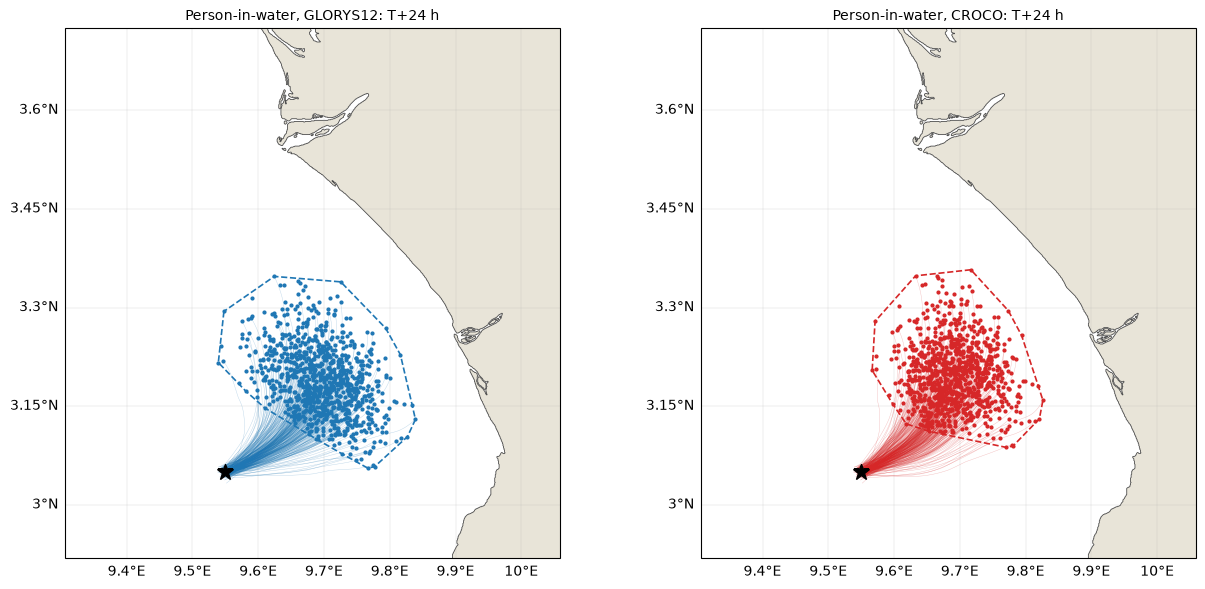

In [31]:
ext = gu.extent_of(*[s.result for s in sar_runs.values()], points=[last_known_position])
fig = plt.figure(figsize=(13, 6))
for k, (label, s) in enumerate(sar_runs.items()):
    ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, k + 1), title=f"Person-in-water, {label}: T+24 h")
    gu.plot_ensemble(ax, s.result, 24, color=["C0", "C3"][k], hull=True)
    ax.plot(*last_known_position, "k*", ms=12, transform=PC, zorder=6)
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_4_2_person_glorys_vs_croco.png", dpi=150); plt.show()

**Q2 — Convex-hull areas and their relative difference** (geometric envelope of one deterministic run, not a probabilistic search area).

In [32]:
areas = {label: gu.hull_area_km2(*gu.state_at(s.result, 24)[["lon", "lat"]].values.T) for label, s in sar_runs.items()}
rel_diff = 100 * (areas["GLORYS12"] - areas["CROCO"]) / areas["CROCO"] if areas["CROCO"] > 0 else np.nan
print(f"24 h convex-hull area: GLORYS12 = {areas['GLORYS12']:.1f} km2, CROCO = {areas['CROCO']:.1f} km2")
print(f"Relative difference (GLORYS12 - CROCO) / CROCO = {rel_diff:+.0f} %")

24 h convex-hull area: GLORYS12 = 703.4 km2, CROCO = 622.5 km2
Relative difference (GLORYS12 - CROCO) / CROCO = +13 %


**Q3 — Shapes and spatial distributions.**

In [33]:
shapes = pd.DataFrame({label: gu.ensemble_shape(*gu.state_at(s.result, 24)[["lon", "lat"]].values.T)
                       for label, s in sar_runs.items()}).T
display(shapes.round(2))
print("Centroid separation GLORYS12 vs CROCO at 24 h: %.1f km" %
      gu.haversine_km(*shapes.loc["GLORYS12", ["centroid_lon", "centroid_lat"]].astype(float),
                      *shapes.loc["CROCO", ["centroid_lon", "centroid_lat"]].astype(float)))

,n,centroid_lon,centroid_lat,std_major_km,std_minor_km,aspect_ratio,major_axis_bearing_deg
GLORYS12,1000.0,9.70,3.19,6.43,4.37,1.47,137.48
CROCO,1000.0,9.69,3.20,5.32,4.74,1.12,163.62


Centroid separation GLORYS12 vs CROCO at 24 h: 1.0 km


**Q4 — Discussion.** Both runs use the same wind, leeway category, seed and stochastic settings
(`drift:current_uncertainty` is not used by Leeway, whose spread comes from the leeway coefficient
perturbations and jibing), so every difference comes from the ocean currents. The *position* of the ensemble
reflects the mean current along the path; its *size and shape* reflect the current **shear and strain** across the
ensemble (a jet or eddy edge stretches it into a filament; a uniform current translates it without deformation).
A finer-resolution, higher-frequency current field contains more small-scale shear, which can *either* stretch
the ensemble (larger hull) *or* keep it coherent inside a jet (smaller hull): there is no rule that "higher
resolution = smaller search area" — read your own numbers.

Implications for reporting: a single deterministic run gives *one* realisation. The difference between the two
forcings (shift of the centroid, change of area) is itself a measure of forcing uncertainty that the individual
hulls do not show. A SAR team should receive the area with this caveat, ideally the union of (or a probability map
built from) several runs with different forcings, leeway categories and release uncertainty, and never a single
hull area quoted to three significant figures.

## Exercise 5.1 — Interaction between particles and the coastline

*Run the Sanaga plastic-release experiment with `coastline_action='stranding'` and `'previous'`.*

In [34]:
sanaga = {"Sanaga": river_mouths["Sanaga"]}
coast_runs = {a: run_plastic(reader_glorys, sanaga, coastline_action=a, outfile=f"sol_5_1_sanaga_{a}.nc")
              for a in ["stranding", "previous"]}

**Q1 — Number and fraction of particles stranded after 20 days**, plus the number of particles lying within 2 km of the coast (a diagnostic that exists for both treatments).

In [35]:
rows = {}
for a, p in coast_runs.items():
    f = gu.state_at(p.result)
    n_seeded = int(np.isfinite(f.lon).sum())
    n_str = int(gu.stranded_mask(p.result).sum())
    near = gu.near_coast(f.lon.values, f.lat.values, 2.0)
    rows[a] = {"seeded": n_seeded, "stranded": n_str, "stranded [%]": 100 * n_str / n_seeded,
               "status categories in file": p.result.status.attrs.get("flag_meanings"),
               "within 2 km of coast": int(near.sum()), "within 2 km of coast [%]": 100 * near.sum() / n_seeded}
pd.DataFrame(rows).T

,seeded,stranded,stranded [%],status categories in file,within 2 km of coast,within 2 km of coast [%]
stranding,500,499,99.8,active stranded,500,100.0
previous,500,0,0.0,active,470,94.0


**Q2 — Spatial distributions.**

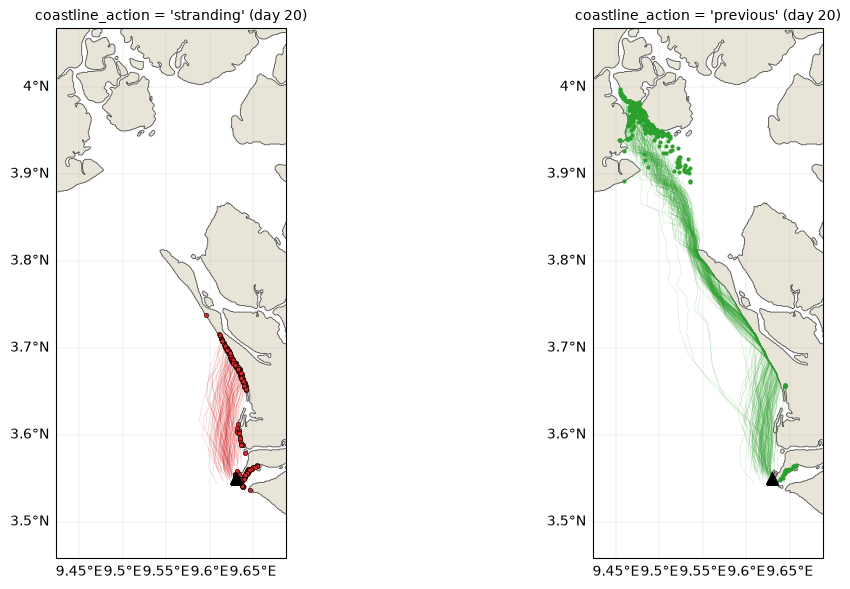

,n,centroid_lon,centroid_lat,std_major_km,std_minor_km,aspect_ratio,major_axis_bearing_deg
stranding,500.0,9.63,3.64,6.86,0.67,10.23,175.10
previous,500.0,9.51,3.89,18.66,1.20,15.56,156.92


In [36]:
ext = gu.extent_of(*[p.result for p in coast_runs.values()])
fig = plt.figure(figsize=(13, 6))
for k, (a, p) in enumerate(coast_runs.items()):
    ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, k + 1), title=f"coastline_action = '{a}' (day 20)")
    gu.plot_ensemble(ax, p.result, color=["C3", "C2"][k], max_tracks=150)
    ax.plot(*river_mouths["Sanaga"], "k^", ms=9, transform=PC, zorder=6)
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_5_1_coastline_action.png", dpi=150); plt.show()
shp = pd.DataFrame({a: gu.ensemble_shape(*gu.state_at(p.result)[["lon", "lat"]].values.T) for a, p in coast_runs.items()}).T
shp.round(2)

**Q3 — What changes (description).** With `'stranding'` a fraction of the particles is flagged `stranded` and frozen
on the coast (black-edged markers), the rest continues offshore. With `'previous'` the stranded fraction is **zero
by construction** — the status `stranded` never appears in the file — but a larger number of particles lies
within a couple of km of the coast, the cloud extends further along the coast and its centroid moves further
from the source (compare the shape tables).

**Q4 — Why, and what it means.** `'stranding'` deactivates a particle the first time a time step would take it onto
land: it is then removed from transport for the rest of the run, so it stops contributing to alongshore
spreading. `'previous'` cancels the offending step and leaves the particle at its last wet position, active; at
the next step it is advected again, and it may hit the coast again, repeatedly. Particles pushed onshore by wind
and currents therefore "slide" along the coastline instead of stopping.

Consequently, the "stranded fraction" is **a property of the numerical coastline treatment, time step and
landmask resolution**, not a measured beaching rate: with `'stranding'` it is an upper bound on first contact
("how much would touch the coast at least once"), with `'previous'` it is zero whatever the physics. Neither
represents beaching, trapping in mangroves/sand, or resuspension by waves and tides; interpreting either as the
real-world amount of plastic deposited on beaches would require a physically-based beaching parameterisation
(probability per unit time near the coast, e.g. Onink et al., 2021) and observations to calibrate it.

## Exercise 5.2 — Effect of the source location on coastal plastic distribution

*Add a third source near Wouri/Douala (`lon=9.70, lat=4.05`), keep the other settings unchanged, compare the three sources.*

In [37]:
sources3 = {**river_mouths, "Wouri": wouri_mouth}
p3 = run_plastic(reader_glorys, sources3, outfile="solution_5_2_plastic_wouri.nc")
ds3 = p3.result

**Q1 — Final particle distributions for the three sources.**

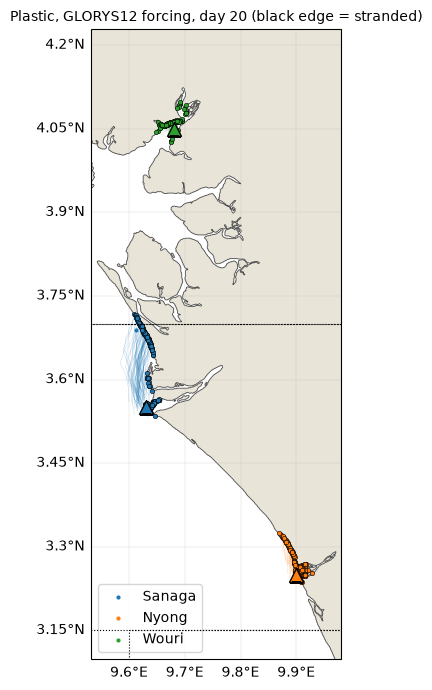

In [38]:
ext = gu.extent_of(ds3)
fig = plt.figure(figsize=(8, 7))
ax = gu.map_axes(fig, extent=ext, title="Plastic, GLORYS12 forcing, day 20 (black edge = stranded)")
for k, (name, (slon, slat)) in enumerate(sources3.items()):
    gu.plot_ensemble(ax, subset_origin(ds3, k), color=f"C{k}", label=name, max_tracks=100)
    ax.plot(slon, slat, "^", color=f"C{k}", mec="k", ms=10, transform=PC, zorder=7)
for name, (x0, x1, y0, y1) in coastal_sectors.items():
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ls=":", lw=0.8, transform=PC, zorder=6))
ax.legend(loc="lower left"); plt.savefig(OUT_DIR / "solution_5_2_three_sources.png", dpi=150); plt.show()

**Q2 — Fraction (%) of each source's particles stranded in each predefined coastal sector** (dotted boxes on the map).

In [39]:
sector_table = pd.DataFrame({name: gu.sector_fractions(ds3, coastal_sectors, origin=k)
                             for k, name in enumerate(sources3)})
sector_table.round(1)

,Sanaga,Nyong,Wouri
Niger Delta coast (Nigeria),0.0,0.0,0.0
Rio del Rey / Bakassi,0.0,0.0,0.0
Bioko Island,0.0,0.0,0.0
Limbe / Mt Cameroon coast,0.0,0.0,0.0
Wouri estuary (Douala),6.0,0.0,100.0
Sanaga-Nyong coast,93.4,100.0,0.0
Kribi coast,0.0,0.0,0.0
Campo / Rio Muni (S of 2.6N),0.0,0.0,0.0
other coast,0.0,0.0,0.0
at sea (not stranded),0.6,0.0,0.0


**Q3 — Coastal sector receiving the largest fraction, for each source.**

In [40]:
coast_only = sector_table.drop(index="at sea (not stranded)")
for name in sources3:
    col = coast_only[name]
    if col.max() > 0:
        print(f"{name:7s}: {col.idxmax()} ({col.max():.1f} % of its particles)")
    else:
        print(f"{name:7s}: no particle stranded within 20 days")

Sanaga : Sanaga-Nyong coast (93.4 % of its particles)
Nyong  : Sanaga-Nyong coast (100.0 % of its particles)
Wouri  : Wouri estuary (Douala) (100.0 % of its particles)


**Q4 — Relation with the simulated surface circulation.** Time-mean surface current of the forcing over the run, and the local current at each source:

Sanaga : mean surface current within 0.15 deg u=-0.081, v=+0.090 m/s (towards 318 deg)
Nyong  : mean surface current within 0.15 deg u=-0.036, v=+0.121 m/s (towards 343 deg)
Wouri  : mean surface current within 0.15 deg u=-0.017, v=+0.025 m/s (towards 326 deg)


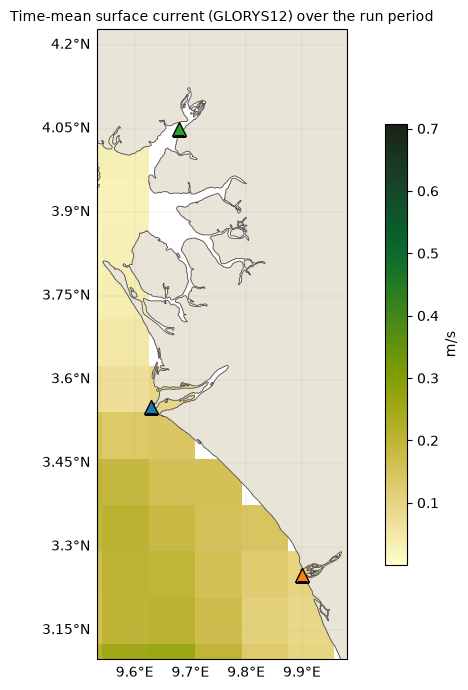

In [41]:
with xr.open_dataset(glorys_file) as g:
    g = g.isel(depth=0) if "depth" in g.dims else g
    t0, t1 = pd.Timestamp(ds3.time.values[0]), pd.Timestamp(ds3.time.values[-1])
    gm = g.sel(time=slice(t0, t1))
    if gm.sizes["time"] == 0:
        warnings.warn("The ocean file does not cover the run period: using its whole record")
        gm = g
    um, vm = gm.uo.mean("time").load(), gm.vo.mean("time").load()
fig = plt.figure(figsize=(8, 7))
ax = gu.map_axes(fig, extent=ext, title="Time-mean surface current (GLORYS12) over the run period")
spd = np.hypot(um, vm)
pm = ax.pcolormesh(um.longitude, um.latitude, spd, cmap="cmo.speed", transform=PC, zorder=1)
sk = max(1, um.sizes["longitude"] // 25)
ax.quiver(um.longitude[::sk], um.latitude[::sk], um[::sk, ::sk], vm[::sk, ::sk], transform=PC, zorder=3, scale=5)
plt.colorbar(pm, ax=ax, shrink=0.7, label="m/s")
for k, (name, (slon, slat)) in enumerate(sources3.items()):
    ax.plot(slon, slat, "^", color=f"C{k}", mec="k", ms=10, transform=PC, zorder=7)
    # mean over the wet cells within +-0.15 deg of the source (the nearest grid point may be land in the model)
    near = dict(longitude=slice(slon - 0.15, slon + 0.15), latitude=slice(slat - 0.15, slat + 0.15))
    uu, vv = float(um.sel(**near).mean()), float(vm.sel(**near).mean())
    print(f"{name:7s}: mean surface current within 0.15 deg u={uu:+.3f}, v={vv:+.3f} m/s "
          f"(towards {np.degrees(np.arctan2(uu, vv)) % 360:.0f} deg)")
plt.savefig(OUT_DIR / "solution_5_2_mean_current.png", dpi=150); plt.show()

*Discussion.* Relate the dominant destination of each source (Q3) to the mean current near it and along the
path: a source sitting in a coherent alongshore flow sends most of its particles downstream along the coast; a
source in a weak or recirculating flow (e.g. inside an estuary or a bay, or close to Bioko) retains particles
near the source or strands them locally; wind drift (2 % windage) adds an onshore/alongshore component that is
the same for all sources. The relationship is **not** the same for all three sources: the Wouri source is
released inside the estuary, where the ocean model has only a few (1/12°) wet cells and no tidal/river-plume
dynamics, so its fate is controlled by the very local, poorly resolved flow and by the coastline treatment;
Sanaga and Nyong are on an open coast directly exposed to the shelf current. Also remember that the mean
current hides variability: a few days of reversed flow can dominate where particles end up. Cross-check the
simulated pathways with the seasonal circulation described by Djakouré et al. (2017).

## Exercise 6.1 — Quantitative comparison of GLORYS12 and CROCO

*Same 2D oil-spill scenario, same wind, time step and seed; only the ocean current reader changes.*

In [42]:
o_g = oil_runs["GENERIC MEDIUM CRUDE"]                                   # GLORYS12 (Exercise 2.1)
o_c = run_oil(reader_croco, outfile="sol_6_1_oil_2D_croco.nc")          # CROCO
table_6_1 = pd.DataFrame({"GLORYS12": summarize(o_g, 72), "CROCO": summarize(o_c, 72)}).T
table_6_1.round(2)

  note: run output ends at 2026-03-03 22:00:00, requested 2026-03-04 02:00:00
  note: run output ends at 2026-03-03 22:00:00, requested 2026-03-04 02:00:00
  note: run output ends at 2026-03-03 22:00:00, requested 2026-03-04 02:00:00


,time to first coastal impact [h],fraction reaching the coast at 72 h [%],convex-hull area at 72 h [km2],first impact lon [deg E],first impact lat [deg N]
GLORYS12,65.0,8.6,62.42,9.91,3.23
CROCO,61.0,99.5,8.10,9.86,3.34


**Q5 — Trajectories and particle distributions.**

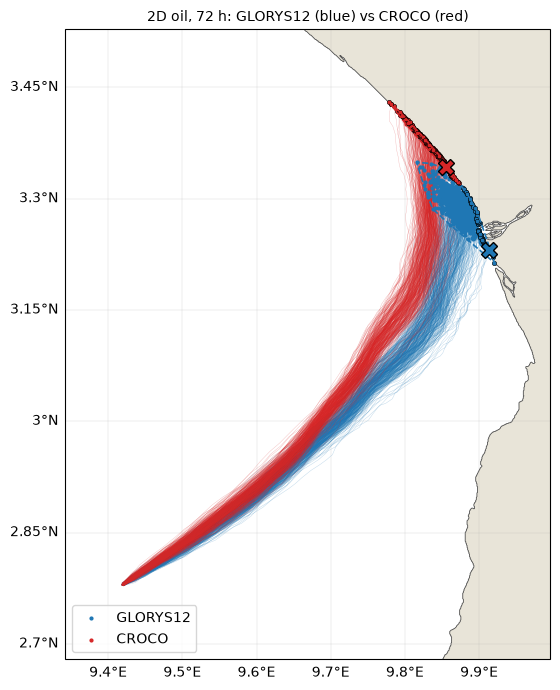

  note: run output ends at 2026-03-03 22:00:00, requested 2026-03-04 02:00:00


,n,centroid_lon,centroid_lat,std_major_km,std_minor_km,aspect_ratio,major_axis_bearing_deg
GLORYS12,1000.0,9.87,3.29,2.77,0.96,2.88,142.43
CROCO,1000.0,9.83,3.37,2.58,0.10,26.80,138.86


Ocean forcing output interval: GLORYS12 = 1 day, 0:00:00 | CROCO = 1 day, 0:00:00


In [43]:
ext = gu.extent_of(o_g.result, o_c.result)
fig = plt.figure(figsize=(8, 7))
ax = gu.map_axes(fig, extent=ext, title="2D oil, 72 h: GLORYS12 (blue) vs CROCO (red)")
gu.plot_ensemble(ax, o_g.result, color="C0", label="GLORYS12", hull=True)
gu.plot_ensemble(ax, o_c.result, color="C3", label="CROCO", hull=True)
for (lab, row), col in zip(table_6_1.iterrows(), ["C0", "C3"]):
    if np.isfinite(row["first impact lon [deg E]"]):
        ax.plot(row["first impact lon [deg E]"], row["first impact lat [deg N]"], "X", color=col, mec="k",
                ms=12, transform=PC, zorder=8)
ax.legend(loc="lower left"); plt.savefig(OUT_DIR / "solution_6_1_glorys_vs_croco.png", dpi=150); plt.show()

shapes61 = pd.DataFrame({lab: gu.ensemble_shape(*gu.state_at(o.result, 72)[["lon", "lat"]].values.T)
                         for lab, o in [("GLORYS12", o_g), ("CROCO", o_c)]}).T
display(shapes61.round(2))
print("Ocean forcing output interval: GLORYS12 =", reader_glorys.time_step, "| CROCO =", reader_croco.time_step)

*Description (Q5).* Using the table, map (crosses = first impact) and shape metrics, describe: which run reaches
the coast first and where; which strands a larger fraction by 72 h; which ensemble is larger/more elongated
and in which direction; and whether the two clouds overlap or are displaced from one another (centroids).

**Q6 — Possible reasons.**
- *Spatial resolution.* ~3 km vs ~9 km: CROCO can represent the narrow coastal jet, the shelf-break front, river
  plume fronts and small eddies; GLORYS12 smooths them. Near the coast GLORYS12 also has fewer wet points, and the
  model coastline is shifted by up to a grid cell relative to the GSHHG coastline used by OpenDrift for stranding.
- *Temporal sampling.* GLORYS12 here is a **daily mean**: tides, inertial oscillations (period ~1–10 days near the
  equator, i.e. partly lost), diurnal sea-breeze responses and any sub-daily variability are absent, and OpenDrift
  interpolates linearly between daily fields. CROCO output is typically hourly to 6-hourly (see the printed
  intervals). Oscillating currents do not produce much net displacement, but they **do** increase dispersion
  and can move particles across fronts: part of any difference in spread or time-to-impact may be due to temporal
  sampling rather than to grid spacing. A clean attribution test is to average the CROCO currents to daily means
  and rerun: the difference between "CROCO hourly" and "CROCO daily" isolates the temporal-sampling effect.
- *Different model physics, forcing and data assimilation*: GLORYS12 assimilates altimetry/SST/in-situ
  observations, the CROCO run is (usually) free-running inside its domain and forced by different
  atmospheric fields and boundary conditions; the two can simply have different mesoscale "weather".
- *Vertical representation*: the "surface" current is the first level (~0.5 m) of GLORYS12 but the top
  s-level of CROCO, whose thickness varies with depth.
- *Randomness*: both runs include random walks (`current_uncertainty`, `wind_uncertainty`): small differences in
  first-impact time (± one output step) are within the noise of a single run.

## Exercise 6.2 — Surface eddy kinetic energy

EKE = ½(u′² + v′²) averaged in time, with anomalies relative to the time mean over the common period (no
spectral filtering: every time scale present in the record contributes).

In [44]:
# --- surface currents of both products ---
g = xr.open_dataset(glorys_file)
ug = (g.uo.isel(depth=0) if "depth" in g.uo.dims else g.uo).load()
vg = (g.vo.isel(depth=0) if "depth" in g.vo.dims else g.vo).load()
ds_croco = xr.open_dataset(croco_file, decode_times=False)
uc, vc = gu.croco_surface_currents(ds_croco, times=reader_croco.times)

# --- common period ---
t0 = max(pd.Timestamp(ug.time.values[0]), pd.Timestamp(uc.time.values[0]))
t1 = min(pd.Timestamp(ug.time.values[-1]), pd.Timestamp(uc.time.values[-1]))
if t1 > t0:
    ug, vg = ug.sel(time=slice(t0, t1)), vg.sel(time=slice(t0, t1))
    uc, vc = uc.sel(time=slice(t0, t1)), vc.sel(time=slice(t0, t1))
    print(f"Common period: {t0} -> {t1}")
else:
    warnings.warn("The two products do not overlap in time: each EKE uses its own full record (not comparable!)")
print(f"GLORYS12: {ug.sizes['time']} fields, CROCO: {uc.sizes['time']} fields")

# --- common region: configured domain, intersected with both products' extents ---
box = [max(lon_min, float(ug.longitude.min()), float(uc.lon.min())), min(lon_max, float(ug.longitude.max()), float(uc.lon.max())),
       max(lat_min, float(ug.latitude.min()), float(uc.lat.min())), min(lat_max, float(ug.latitude.max()), float(uc.lat.max()))]
if box[0] >= box[1] or box[2] >= box[3]:
    warnings.warn("Configured domain does not intersect both products: using the overlap of the two products")
    box = [max(float(ug.longitude.min()), float(uc.lon.min())), min(float(ug.longitude.max()), float(uc.lon.max())),
           max(float(ug.latitude.min()), float(uc.lat.min())), min(float(ug.latitude.max()), float(uc.lat.max()))]
print("Region:", np.round(box, 2))

eke_g = gu.time_mean_eke(ug, vg).sel(longitude=slice(box[0], box[1]), latitude=slice(box[2], box[3]))
eke_c = gu.time_mean_eke(uc, vc)
inbox = (eke_c.lon >= box[0]) & (eke_c.lon <= box[1]) & (eke_c.lat >= box[2]) & (eke_c.lat <= box[3])
eke_c = eke_c.where(inbox)

Common period: 2026-03-01 00:00:00 -> 2026-05-29 00:00:00
GLORYS12: 90 fields, CROCO: 90 fields
Region: [ 3.97 12.23 -5.21  5.51]


**Q1 — EKE maps** (same colour scale; cm²/s²).

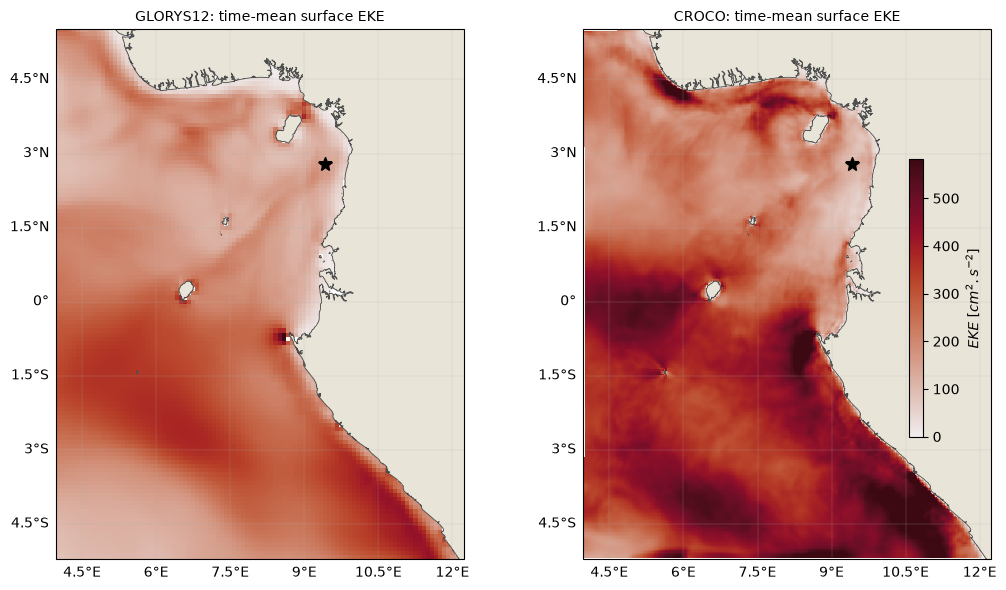

In [61]:
vmax = float(np.nanpercentile(np.r_[eke_g.values.ravel(), eke_c.values.ravel()] * 1e4, 98))
fig = plt.figure(figsize=(13, 6))
for k, (label, e, x, y) in enumerate([("GLORYS12", eke_g, eke_g.longitude, eke_g.latitude),
                                      ("CROCO", eke_c, eke_c.lon, eke_c.lat)]):
    ax = gu.map_axes(fig, extent=box, subplot=(1, 2, k + 1), title=f"{label}: time-mean surface EKE")
    pm = ax.pcolormesh(x, y, e * 1e4, cmap="cmo.amp", vmin=0, vmax=vmax, transform=PC, zorder=1, shading="auto")
    ax.plot(release_lon, release_lat, "k*", ms=10, transform=PC, zorder=5)
plt.colorbar(pm, ax=fig.axes, shrink=0.6, anchor=(1.3, 0.5), label="$EKE$ $[cm^{2}.s^{-2}]$")
plt.savefig(OUT_DIR / "solution_6_2_eke_comparison.png", dpi=250); plt.show()

**Q2 — Spatial structure and high-EKE regions** (cells above each product's 90th percentile).

In [46]:
def eke_summary(e, lon, lat):
    # lon, lat: 2D arrays of the same shape as the EKE field
    v = e.values
    ok = np.isfinite(v)
    thr = np.nanpercentile(v[ok], 90)
    hi = ok & (v >= thr)
    imax = np.nanargmax(np.where(ok, v, -np.inf))
    return {"mean EKE [cm2/s2]": 1e4 * np.nanmean(v), "median EKE [cm2/s2]": 1e4 * np.nanmedian(v),
            "90th pct [cm2/s2]": 1e4 * thr, "max EKE [cm2/s2]": 1e4 * v.flat[imax],
            "max at lon": lon.flat[imax], "max at lat": lat.flat[imax],
            "high-EKE cells: mean lon": lon[hi].mean(), "high-EKE cells: mean lat": lat[hi].mean(),
            "number of wet cells": int(ok.sum())}

eke_stats = pd.DataFrame({"GLORYS12": eke_summary(eke_g, *np.meshgrid(eke_g.longitude.values, eke_g.latitude.values)),
                          "CROCO": eke_summary(eke_c, eke_c.lon.values, eke_c.lat.values)}).T
eke_stats.round(2)

,mean EKE [cm2/s2],median EKE [cm2/s2],90th pct [cm2/s2],max EKE [cm2/s2],max at lon,max at lat,high-EKE cells: mean lon,high-EKE cells: mean lat,number of wet cells
GLORYS12,214.39,204.17,345.64,730.56,8.58,-0.67,7.57,-2.74,8548.0
CROCO,331.93,346.63,498.81,852.70,8.56,-0.72,8.02,-2.74,75928.0


**Q3 — Description.** From the maps and the table describe: the overall EKE level of each product (mean, median,
max), where the high-EKE regions are (along the coast? at the shelf break? offshore? in the lee of islands or
capes?), their typical size (a few grid cells? elongated bands?), and how "patchy" each field is. Note also the
number of wet cells near the coast in each product.

**Q4 — Possible reasons.**
- *Grid resolution*: variability at scales smaller than ~4–5 grid cells (≈40 km for GLORYS12, ≈12–15 km for CROCO)
  is damped by numerical diffusion/viscosity, so CROCO can hold energy in small eddies, filaments and coastal jets
  that GLORYS12 cannot represent; near the coast GLORYS12 also has fewer wet cells.
- *Temporal sampling*: EKE is computed from the fields available. Daily means remove tides, inertial and diurnal
  signals, which may contribute strongly to u′ in the CROCO record if it is hourly/6-hourly: part of the higher
  CROCO EKE can be *temporal* rather than *mesoscale* variability.
- *Length of the averaging period*: with a few days to weeks of data, the "time-mean" is itself noisy, a single
  eddy passing through dominates the EKE, and slow (seasonal) changes are counted as "eddy" energy; a few days is
  far from a climatological EKE.
- *Different dynamics and data*: data assimilation in GLORYS12 constrains the mesoscale to observed positions;
  a regional model generates its own (intrinsic) eddies that need not coincide with reality.

**Q5 — Relation with the transport differences of Exercise 6.1.**

In [47]:
from scipy.spatial import cKDTree

def sample(e, lon2d, lat2d, lon, lat):
    ok = np.isfinite(e.values.ravel())
    tree = cKDTree(np.column_stack([lon2d.ravel()[ok], lat2d.ravel()[ok]]))
    _, i = tree.query(np.column_stack([lon, lat]))
    return e.values.ravel()[ok][i]

lg2, la2 = np.meshgrid(eke_g.longitude.values, eke_g.latitude.values)
rows = {}
for label, o, e, lo, la in [("GLORYS12", o_g, eke_g, lg2, la2), ("CROCO", o_c, eke_c, eke_c.lon.values, eke_c.lat.values)]:
    lon_t, lat_t = o.result.lon.values.ravel(), o.result.lat.values.ravel()
    ok = np.isfinite(lon_t)
    rows[label] = {"EKE at release point [cm2/s2]": 1e4 * sample(e, lo, la, [release_lon], [release_lat])[0],
                   "mean EKE along trajectories [cm2/s2]": 1e4 * np.mean(sample(e, lo, la, lon_t[ok], lat_t[ok])),
                   "72 h hull area [km2] (Ex. 6.1)": table_6_1.loc[label, "convex-hull area at 72 h [km2]"]}
pd.DataFrame(rows).T.round(2)

,EKE at release point [cm2/s2],mean EKE along trajectories [cm2/s2],72 h hull area [km2] (Ex. 6.1)
GLORYS12,151.90,78.35,62.42
CROCO,122.55,90.79,8.10


A high-EKE region is a region where the *current varies a lot in time* at a given point. It increases transport
uncertainty in the simulations only if (i) the particles actually travel through it during the run, and (ii) the
variability occurs on time and space scales comparable to the ensemble (eddies or fronts the size of the
particle cloud stretch it; a basin-scale seasonal change translates it). A release point sitting just outside a
high-EKE band may give almost identical GLORYS12/CROCO trajectories over 72 h, while a release in (or drifting
into) an eddy-rich area can diverge quickly. Compare the EKE sampled at the release point and along the
trajectories with the difference in hull areas and centroids found in Exercise 6.1: the correspondence, if any,
depends on where the release sits relative to the high-EKE structures, not on the domain-mean EKE.

## Exercise 6.3 — SAR briefing

The briefing below is generated from the numbers computed in Exercise 4.2 (person-in-water, 24 h), so that it
stays correct when the forcing files change. Complete it with your own interpretation of the maps.

In [48]:
shape_g, shape_c = shapes.loc["GLORYS12"], shapes.loc["CROCO"]
sep = gu.haversine_km(float(shape_g.centroid_lon), float(shape_g.centroid_lat), float(shape_c.centroid_lon), float(shape_c.centroid_lat))
larger = "GLORYS12" if areas["GLORYS12"] > areas["CROCO"] else "CROCO"
display(Markdown(f'''
> **SAR drift briefing — person in the water (last known position {last_known_position[1]:.2f}°N, {last_known_position[0]:.2f}°E,
> {incident_time:%d %b %Y %H:%M} UTC), situation at T+24 h**
>
> * **Simulated area — global ocean model (GLORYS12, ~9 km, daily):** {areas["GLORYS12"]:.0f} km²
> * **Simulated area — regional ocean model (CROCO):** {areas["CROCO"]:.0f} km²
> * **Difference:** the {larger}-based area is {abs(rel_diff):.0f} % {"larger" if rel_diff > 0 else "smaller"} (relative to CROCO) ;
>   the two drift centres are **{sep:.1f} km apart**.
> * **Shape:** GLORYS12 cloud ~{shape_g.std_major_km:.1f} × {shape_g.std_minor_km:.1f} km (1 std, axis towards {shape_g.major_axis_bearing_deg:.0f}°);
>   CROCO cloud ~{shape_c.std_major_km:.1f} × {shape_c.std_minor_km:.1f} km (axis towards {shape_c.major_axis_bearing_deg:.0f}°).
>
> *These areas are the convex envelope of 1000 simulated positions from **one deterministic run per model**. They are not
> probability-weighted search areas and do not include the uncertainty of the forcing itself.*
>
> **Why the two differ.** Same wind, same object type: the difference comes from the ocean currents. The regional model
> resolves narrower coastal currents and eddies and is output more frequently; the global product is smoother and,
> as used here, a daily average (tidal and other sub-daily currents are absent). Either can be closer to reality on a
> given day.
>
> **Limitations.** Single runs (no ensemble); one leeway category ("PIW, unknown state") — a different state of the
> person changes the drift; daily-mean vs higher-frequency currents; wind from a reanalysis, not a forecast; no
> validation against drifters on this date.
>
> **Recommendation.** Treat the **union of the two areas** (and the zone between the two drift centres) as the
> first-priority area, and request an ensemble product before committing additional assets.
'''))


> **SAR drift briefing — person in the water (last known position 3.05°N, 9.55°E,
> 01 Mar 2026 06:00 UTC), situation at T+24 h**
>
> * **Simulated area — global ocean model (GLORYS12, ~9 km, daily):** 703 km²
> * **Simulated area — regional ocean model (CROCO):** 623 km²
> * **Difference:** the GLORYS12-based area is 13 % larger (relative to CROCO) ;
>   the two drift centres are **1.0 km apart**.
> * **Shape:** GLORYS12 cloud ~6.4 × 4.4 km (1 std, axis towards 137°);
>   CROCO cloud ~5.3 × 4.7 km (axis towards 164°).
>
> *These areas are the convex envelope of 1000 simulated positions from **one deterministic run per model**. They are not
> probability-weighted search areas and do not include the uncertainty of the forcing itself.*
>
> **Why the two differ.** Same wind, same object type: the difference comes from the ocean currents. The regional model
> resolves narrower coastal currents and eddies and is output more frequently; the global product is smoother and,
> as used here, a daily average (tidal and other sub-daily currents are absent). Either can be closer to reality on a
> given day.
>
> **Limitations.** Single runs (no ensemble); one leeway category ("PIW, unknown state") — a different state of the
> person changes the drift; daily-mean vs higher-frequency currents; wind from a reanalysis, not a forecast; no
> validation against drifters on this date.
>
> **Recommendation.** Treat the **union of the two areas** (and the zone between the two drift centres) as the
> first-priority area, and request an ensemble product before committing additional assets.


**Discussion — how the ocean forcing affects SAR planning.** The forcing changes both *where* the search is
centred and *how large* the area is; with a fixed number of assets, a displaced or under-sized area directly lowers
the probability of success, while an over-sized one dilutes search effort. What an operational team would want
before committing assets: (i) an **ensemble** (several ocean and wind forcings, perturbed leeway categories and
last-known-position/time uncertainty) expressed as a **probability map** and probability-of-containment contours;
(ii) the **forecast** (not reanalysis) wind and current, with its valid time and next update; (iii) any
**observations**: drifting buoys (SLDMB) deployed at the scene, HF radar, AIS tracks of nearby vessels, sightings;
(iv) survival-time and detectability information for the search object, to choose the search pattern and priorities.

## Exercise 6.4 — Plastic transport under different ocean forcings

*Repeat the Wouri-source plastic simulation with CROCO and compare with GLORYS12.* The GLORYS12 Wouri particles
are taken from the three-source run of Exercise 5.2 (sources do not interact, so this is equivalent to a
Wouri-only run with the same settings).

In [49]:
wouri_glorys = subset_origin(ds3, list(sources3).index("Wouri"))
wouri_croco = run_plastic(reader_croco, {"Wouri": wouri_mouth}, outfile="solution_6_4_plastic_croco.nc").result
wouri_runs = {"GLORYS12": wouri_glorys, "CROCO": wouri_croco}

**Q1 — Final particle distributions.**

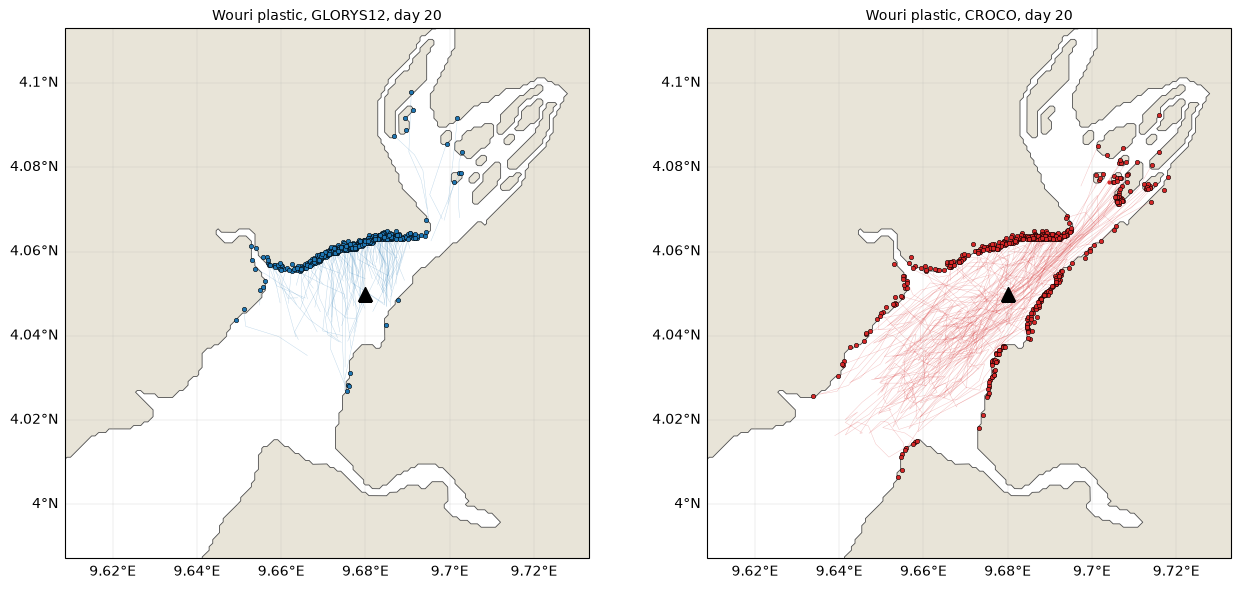

In [50]:
ext = gu.extent_of(*wouri_runs.values(), points=[wouri_mouth])
fig = plt.figure(figsize=(13, 6))
for k, (label, ds) in enumerate(wouri_runs.items()):
    ax = gu.map_axes(fig, extent=ext, subplot=(1, 2, k + 1), title=f"Wouri plastic, {label}, day 20")
    gu.plot_ensemble(ax, ds, color=["C0", "C3"][k], max_tracks=150)
    ax.plot(*wouri_mouth, "k^", ms=10, transform=PC, zorder=7)
plt.tight_layout(); plt.savefig(OUT_DIR / "solution_6_4_wouri_glorys_vs_croco.png", dpi=150); plt.show()

**Q2–Q4 — Stranded fraction, mean latitude and spread of the stranding locations.**

In [51]:
rows = {}
for label, ds in wouri_runs.items():
    f = gu.state_at(ds)
    strd = gu.stranded_mask(ds)
    n = int(np.isfinite(f.lon).sum())
    lon_s, lat_s = f.lon.values[strd], f.lat.values[strd]
    r = {"released": n, "stranded": int(strd.sum()), "stranded [%]": 100 * strd.sum() / max(n, 1)}
    if strd.sum() > 0:
        x, y = gu._local_xy_km(lon_s, lat_s)
        r.update({"mean lat of stranded [deg N]": lat_s.mean(), "mean lon of stranded [deg E]": lon_s.mean(),
                  "std lat [km]": np.std(y), "std lon [km]": np.std(x),
                  "lat range [deg]": lat_s.max() - lat_s.min(),
                  "IQR lat [deg]": np.subtract(*np.percentile(lat_s, [75, 25])),
                  "hull area of stranding points [km2]": gu.hull_area_km2(lon_s, lat_s)})
    rows[label] = r
display(pd.DataFrame(rows).T.round(3))
pd.DataFrame({label: gu.sector_fractions(ds, coastal_sectors) for label, ds in wouri_runs.items()}).round(1)

,released,stranded,stranded [%],mean lat of stranded [deg N],mean lon of stranded [deg E],std lat [km],std lon [km],lat range [deg],IQR lat [deg],hull area of stranding points [km2]
GLORYS12,500.0,500.0,100.0,4.061,9.677,0.622,0.982,0.071,0.003,24.536
CROCO,500.0,499.0,99.8,4.058,9.684,1.494,1.688,0.086,0.012,37.237


,GLORYS12,CROCO
Niger Delta coast (Nigeria),0.0,0.0
Rio del Rey / Bakassi,0.0,0.0
Bioko Island,0.0,0.0
Limbe / Mt Cameroon coast,0.0,0.0
Wouri estuary (Douala),100.0,99.8
Sanaga-Nyong coast,0.0,0.0
Kribi coast,0.0,0.0
Campo / Rio Muni (S of 2.6N),0.0,0.0
other coast,0.0,0.0
at sea (not stranded),0.0,0.2


**Q5 — Description.** State which run strands more particles, whether the stranding locations move north or south
(mean latitude) and whether they are more concentrated or more spread (std, range, IQR, hull of stranding points,
sector table); and how the particles that remain at sea are distributed (inside the estuary, along the shelf,
offshore).

**Q6 — Physical reasons.** The Wouri source lies inside a large, shallow, tidal estuary. Its fate depends on
(i) the estuarine/shelf circulation near the mouth, which a ~9 km grid barely represents (few wet points,
coastline displaced) while a finer grid represents better; (ii) the along-shelf current and its reversals, which
the two models may represent with different strength and timing; (iii) the river plume (buoyant outflow and its
front), which is only present if the model includes realistic river discharge; (iv) tides, absent from daily
means and possibly from the CROCO run too — check the CROCO configuration. The resolution-vs-temporal-sampling
caveat of Exercise 6.1 applies fully here: in an estuary, tidal currents are often the largest currents, so a
difference between an hourly and a daily-mean forcing may exceed the effect of grid spacing. The stranding
numbers are also sensitive to the coastline treatment (Exercise 5.1): a model with more wet cells near the coast
lets particles approach the GSHHG coastline more often, which alone can increase the stranded fraction.

## Exercise 7.1 — Forecast versus reanalysis

*Archived GFS forecast cycle vs ERA5 for the same valid times and domain.* `gu.download_gfs_10m_wind` fetches the
10 m wind of an archived cycle from the NOAA Open Data archive on AWS (GRIB2, decoded with `cfgrib`).

In [ ]:
if not gfs_archive_file.exists():
    try:
        gu.download_gfs_10m_wind(gfs_cycle, gfs_leads, (lon_min - 1, lon_max + 1, lat_min - 1, lat_max + 1), gfs_archive_file)
    except Exception as err:
        print(f"GFS download failed ({err}); place a GFS 10 m wind NetCDF file at {gfs_archive_file}")

have_gfs = gfs_archive_file.exists()
if have_gfs:
    gfs = xr.open_dataset(gfs_archive_file)
    era = xr.open_dataset(wind_file).sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    common = np.intersect1d(gfs.time.values, era.time.values)
    print(f"GFS cycle {gfs_cycle:%Y-%m-%d %HZ}: {gfs.sizes['time']} lead times, {len(common)} valid times also in ERA5")
    have_gfs = len(common) > 0
    if have_gfs:
        era = era.sel(time=common)
        gfs_i = gfs.sel(time=common).interp(longitude=era.longitude, latitude=era.latitude)   # GFS on the ERA5 grid
        spd_e, spd_g = np.hypot(era.x_wind, era.y_wind), np.hypot(gfs_i.x_wind, gfs_i.y_wind)
        dir_e, dir_g = gu.wind_direction_from(era.x_wind, era.y_wind), gu.wind_direction_from(gfs_i.x_wind, gfs_i.y_wind)
        ddir = ((dir_g - dir_e + 180) % 360 - 180).where((spd_e > 2) & (spd_g > 2))   # GFS - ERA5, in [-180, 180)
        lead = ((common - np.datetime64(gfs_cycle)) / np.timedelta64(1, "h")).astype(int)
    else:
        print("No common valid time: choose gfs_cycle inside the period of the ERA5 file", wind_file)

**Q1–Q5 — Statistics over the domain and all common valid times, and per lead time** (direction differences only where both winds exceed 2 m/s).

In [ ]:
if have_gfs:
    diff = spd_g - spd_e
    overall = pd.Series({
        "mean wind speed ERA5 [m/s]": float(spd_e.mean()), "mean wind speed GFS [m/s]": float(spd_g.mean()),
        "max wind speed ERA5 [m/s]": float(spd_e.max()), "max wind speed GFS [m/s]": float(spd_g.max()),
        "mean difference GFS-ERA5 [m/s]": float(diff.mean()), "max |difference| [m/s]": float(abs(diff).max()),
        "RMS difference [m/s]": float(np.sqrt((diff ** 2).mean())),
        "mean direction difference GFS-ERA5 [deg]": float(ddir.mean()),
        "mean |direction difference| [deg]": float(abs(ddir).mean()),
        "max |direction difference| [deg]": float(abs(ddir).max())})
    display(overall.round(2).to_frame("value"))
    per_lead = pd.DataFrame({
        "mean ERA5": spd_e.mean(["latitude", "longitude"]).values, "mean GFS": spd_g.mean(["latitude", "longitude"]).values,
        "max ERA5": spd_e.max(["latitude", "longitude"]).values, "max GFS": spd_g.max(["latitude", "longitude"]).values,
        "mean diff": diff.mean(["latitude", "longitude"]).values, "max |diff|": abs(diff).max(["latitude", "longitude"]).values,
        "mean |ddir| [deg]": abs(ddir).mean(["latitude", "longitude"]).values}, index=pd.Index(lead, name="lead [h]"))
    display(per_lead.round(2))

**Wind fields and difference field** (at a 24 h lead time, or the closest available) and the time-mean difference.

In [ ]:
if have_gfs:
    it = int(np.argmin(np.abs(lead - 24)))
    ext = [lon_min, lon_max, lat_min, lat_max]
    fig = plt.figure(figsize=(15, 9))
    vmax = float(max(spd_e.isel(time=it).max(), spd_g.isel(time=it).max()))
    for k, (label, s, ds) in enumerate([("ERA5", spd_e, era), ("GFS", spd_g, gfs_i)]):
        ax = gu.map_axes(fig, extent=ext, subplot=(2, 2, k + 1), title=f"{label} 10 m wind, {pd.Timestamp(common[it]):%d %b %H UTC} (lead {lead[it]} h)")
        pm = ax.pcolormesh(era.longitude, era.latitude, s.isel(time=it), cmap="cmo.speed", vmin=0, vmax=vmax, transform=PC)
        ax.quiver(era.longitude[::2], era.latitude[::2], ds.x_wind.isel(time=it)[::2, ::2], ds.y_wind.isel(time=it)[::2, ::2], transform=PC)
        plt.colorbar(pm, ax=ax, shrink=0.8, label="m/s")
    for k, (label, d) in enumerate([(f"GFS - ERA5 speed, lead {lead[it]} h", diff.isel(time=it)), ("GFS - ERA5 speed, mean over all leads", diff.mean("time"))]):
        ax = gu.map_axes(fig, extent=ext, subplot=(2, 2, k + 3), title=label)
        lim = float(abs(d).max())
        pm = ax.pcolormesh(era.longitude, era.latitude, d, cmap="RdBu_r", vmin=-lim, vmax=lim, transform=PC)
        plt.colorbar(pm, ax=ax, shrink=0.8, label="m/s")
    plt.tight_layout(); plt.savefig(OUT_DIR / "solution_7_1_gfs_vs_era5.png", dpi=150); plt.show()

**Description.** Describe where the differences are largest (coastal band vs open ocean, near Mount Cameroon /
Bioko, near convective areas), whether GFS is systematically stronger or weaker than ERA5 (sign of the mean
difference), whether the differences grow with lead time (per-lead table) and whether direction differences are
concentrated in light-wind areas.

**Possible reasons.**
- *Forecast lead time*: a forecast drifts away from the true atmospheric state as lead time increases (errors in
  the position/timing of convective systems, of the monsoon flow); a reanalysis has no lead time.
- *Assimilation*: ERA5 is a re-analysis — observations over the whole assimilation window (including some
  received after the forecast was issued) constrain it at every analysis time; the GFS forecast only used
  observations available before its initial time, with a different assimilation system.
- *Resolution and physics*: both are distributed on 0.25°, but the native models differ (ERA5 ~31 km, GFS ~13 km
  FV3), with different boundary-layer, convection and land–sea contrast parameterisations: sea breezes, coastal
  convergence and orographic effects of Mount Cameroon/Bioko are represented differently.
- *Interpolation / grids*: GFS is interpolated here onto the ERA5 grid, and land–sea masks differ at the coast.
- Neither is ground truth: both should be compared with buoy / scatterometer (ASCAT) winds where available.

## Exercise 7.2 — Global versus regional ocean forecasting

*Same 72 h oil-spill scenario, forced by (a) a global ocean forecast (CMEMS analysis & forecast) and (b) the CROCO
regional forecast.* If no separate global forecast file is available, the global product of `data/` is used as a
stand-in (the sample MERCATOR file is itself a CMEMS analysis/forecast product).

In [ ]:
if glorys_fc_file.exists():
    reader_global_fc = reader_netCDF_CF_generic.Reader(str(glorys_fc_file))
else:
    print(f"{glorys_fc_file} not found: using {glorys_file} as the global forecast")
    reader_global_fc = reader_glorys
if Path(croco_fc_file) == Path(croco_file):
    reader_regional_fc = reader_croco
else:
    fc_masks = gu.croco_gridfile(croco_fc_file, DATA_DIR / f"{Path(croco_fc_file).stem}_uv_masks.nc")
    reader_regional_fc = reader_ROMS_native.Reader(str(croco_fc_file), gridfile=fc_masks and str(fc_masks))
wind_fc = reader_netCDF_CF_generic.Reader(str(gfs_file)) if gfs_file.exists() else reader_wind
print("Wind forcing:", wind_fc.name)

# Common start: first time covered by both forecasts (and 72 h after it, if possible)
fc_t0 = max(reader_global_fc.start_time, reader_regional_fc.start_time)
if fc_t0 + timedelta(hours=72) > min(reader_global_fc.end_time, reader_regional_fc.end_time):
    warnings.warn("The two forecasts do not share a 72 h window: using the scenario release time")
    fc_t0 = release_time
print("Forecast runs start at", fc_t0)
fc_runs = {"global forecast": run_oil(reader_global_fc, time=fc_t0, wind_reader=wind_fc, outfile="solution_7_2_global_fc.nc"),
           "CROCO forecast":  run_oil(reader_regional_fc, time=fc_t0, wind_reader=wind_fc, outfile="solution_7_2_croco_fc.nc")}

**Q1 — Trajectories, distributions, time to first impact, fraction reaching the coast, footprint.**

In [ ]:
table_7_2 = pd.DataFrame({k: summarize(o, 72) for k, o in fc_runs.items()}).T
display(table_7_2.round(2))
ext = gu.extent_of(*[o.result for o in fc_runs.values()])
fig = plt.figure(figsize=(8, 7))
ax = gu.map_axes(fig, extent=ext, title="72 h oil forecast: global (blue) vs CROCO (red)")
for (k, o), col in zip(fc_runs.items(), ["C0", "C3"]):
    gu.plot_ensemble(ax, o.result, color=col, label=k, hull=True)
ax.legend(loc="lower left"); plt.savefig(OUT_DIR / "solution_7_2_forecasts.png", dpi=150); plt.show()

**Q2 — Summary.** Summarise from the table and map: which forecast predicts the earlier landfall and where, the
fraction reaching the coast, the footprint size/shape and the displacement between the two ensembles.

**Q3 — Sources of uncertainty.**

| Source | Forecast-specific? | Comment |
|---|---|---|
| Initial state of the ocean model | **yes** | a forecast starts from an analysis that may be days old in some variables; errors in eddy/front positions grow with lead time |
| Atmospheric forcing (wind, fluxes) | **yes** | forecast winds (GFS/ECMWF) degrade with lead time — Exercise 7.1 quantifies this; in hindcast mode a reanalysis is used |
| Boundary conditions of the regional model | **yes** (and resolution) | the CROCO forecast inherits the *forecast* errors of its parent global model at its open boundaries |
| Lead time of the drift forecast itself | **yes** | errors accumulate along the trajectory; report a valid-until time and re-run with each new cycle |
| Spin-up of the regional model | mostly forecast | small scales are not in the initial condition and need hours–days to develop |
| Grid resolution (coastal jets, eddies, plumes, coastline) | no — resolution | present in hindcast as well (Part 6) |
| Temporal sampling of the currents (daily vs hourly) | no — output choice | present in hindcast as well (Exercise 6.1) |
| Missing processes (tides, waves/Stokes drift, rivers) | no | configuration choices, common to hindcast and forecast |

A useful operational check that isolates the forecast-specific part is **forecast consistency**: run the same
spill with yesterday's and today's cycles; the displacement between the two is a lower bound of the forecast
uncertainty at that lead time.

## Exercise 7.3 — Global and regional ocean models in operational forecasting

In [ ]:
g61, c61 = table_6_1.loc["GLORYS12"], table_6_1.loc["CROCO"]
display(Markdown(f'''
**Example from this school (Exercise 6.1).** For the Kribi 2D oil scenario, the GLORYS12-forced run gave a first
coastal impact after **{g61.iloc[0]:.0f} h** and {g61.iloc[1]:.0f} % of elements on the coast at 72 h, the CROCO-forced run
**{c61.iloc[0]:.0f} h** and {c61.iloc[1]:.0f} %; the 72 h envelopes were {g61.iloc[2]:.0f} km² and {c61.iloc[2]:.0f} km².
(NaN = no coastal impact within 72 h.) The CROCO run exists only because GLORYS12 provides its initial and boundary
conditions: the global model sets the large-scale state, the regional model adds the coastal detail, and the
difference between the two is itself a useful indicator of the uncertainty of the coastal prediction.
'''))

**Model briefing — why use both global and regional ocean models?**

- **Spatial resolution.** Global systems (1/12°, ~9 km) resolve the large-scale circulation and large eddies;
  regional models (1/36°, ~3 km or finer) resolve coastal jets, shelf fronts, river plumes, small eddies and a
  more realistic coastline and bathymetry — the scales that decide which beach is hit or where a person drifts.
- **Computational cost.** Cost grows roughly with the cube of the refinement factor (two horizontal dimensions
  plus a shorter time step): a global model at regional resolution is unaffordable for daily operations, a
  regional model on a limited domain is affordable on a modest cluster.
- **Representation of coastal processes.** Regional configurations can include tides, river discharge,
  wetting/drying, higher vertical resolution on the shelf and locally tuned mixing; global products often
  provide daily means without tides.
- **Initial and boundary conditions.** A regional model needs open-boundary and initial conditions: they come from
  the global model. The regional forecast can never be better than its boundaries at scales the global model
  controls (remote waves, large-scale currents entering the domain).
- **Atmospheric forcing.** Both need wind and fluxes; a regional ocean model can be coupled with a regional
  atmospheric model (WRF) that resolves sea breezes and orographic winds (Mount Cameroon), which global
  atmospheric forecasts (0.25°) smooth out.
- **Availability of forecasts.** Global forecasts (CMEMS, 10 days, daily) are free, reliable and always available;
  a regional system depends on local computing, staff and data pipelines — the global product is the fallback
  when the regional run fails.
- **Observations and data assimilation.** Global systems assimilate satellite altimetry, SST and Argo profiles
  routinely; regional systems in the Gulf of Guinea are often not data-assimilative, so their small-scale features
  are realistic in character but not necessarily in position. Assimilating local observations (tide gauges,
  HF radar, gliders) is where regional systems can gain the most.
- **Forecast uncertainty.** Using both gives two estimates of the same situation: their spread is a cheap,
  first-order uncertainty indicator; ensembles (perturbed forcing/initial conditions) are the proper tool.

**Conclusion.** Global and regional models are complementary rather than competing: the global model provides the
large-scale state, initial and boundary conditions, and a robust fallback; the regional model adds coastal detail
where decisions are made. In an operational chain, drift forecasts are best produced with both and presented
together, with the difference between them communicated as uncertainty (see the example above).

## Closing note for instructors

The code in this notebook computes every requested quantity from the files in `data/`; the discussion texts
describe the expected physical behaviour and the reasoning to apply, not reference numbers. Encourage students to
report and discuss their *own* numbers and to explain any departure from the expected pattern — e.g. a weak-wind,
weak-current period may show little GLORYS12-vs-CROCO difference, which is an equally valid and instructive outcome.